In [3]:
# Import pandas for creating and working with tabular data
import pandas as pd

# Import numpy for generating random numerical values
import numpy as np

# Import random for generating random categorical values
import random

# Set a seed so that we get the same random dataset
# whenever we run the code again
np.random.seed(42)
random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# We want to simulate 2,000 different customers
num_customers = 2000

# Create unique customer IDs
# Example: C0001, C0002, C0003, ...
customer_ids = [
    f"C{i:04d}"
    for i in range(1, num_customers + 1)
]

# Show the first 10 customer IDs
print(customer_ids[:10])

# Show the total number of customers
print("Total customers:", len(customer_ids))

['C0001', 'C0002', 'C0003', 'C0004', 'C0005', 'C0006', 'C0007', 'C0008', 'C0009', 'C0010']
Total customers: 2000


In [5]:
# We want to simulate 10,000 payment transactions
num_transactions = 10000

# Create a unique ID for every transaction
# Example: TXN000001, TXN000002, TXN000003, ...
transaction_ids = [
    f"TXN{i:06d}"
    for i in range(1, num_transactions + 1)
]

# Randomly assign one of our 2,000 customers to each transaction
# This means one customer can have multiple transactions
transaction_customer_ids = np.random.choice(
    customer_ids,
    size=num_transactions
)

# Generate a random transaction amount between ₹100 and ₹25,000
# np.round(..., 2) keeps the amount to 2 decimal places
amounts = np.round(
    np.random.uniform(100, 25000, num_transactions),
    2
)

# Check a few transaction IDs
print("First 10 transaction IDs:")
print(transaction_ids[:10])

# Check a few customers assigned to transactions
print("\nFirst 10 customer IDs:")
print(transaction_customer_ids[:10])

# Check a few transaction amounts
print("\nFirst 10 transaction amounts:")
print(amounts[:10])

# Confirm the total number of transactions
print("\nTotal transactions:", len(transaction_ids))

First 10 transaction IDs:
['TXN000001', 'TXN000002', 'TXN000003', 'TXN000004', 'TXN000005', 'TXN000006', 'TXN000007', 'TXN000008', 'TXN000009', 'TXN000010']

First 10 customer IDs:
['C1127' 'C1460' 'C0861' 'C1295' 'C1131' 'C1096' 'C1725' 'C1045' 'C1639'
 'C0122']

First 10 transaction amounts:
[11445.67 12102.23 18968.64  7119.77  8019.19 23123.58  1499.98 12192.29
 22828.74 15298.04]

Total transactions: 10000


In [6]:
# These are the payment methods available in our simulated system
payment_methods = [
    "UPI",
    "Credit Card",
    "Debit Card",
    "Net Banking",
    "Wallet"
]

# Randomly assign a payment method to each transaction
# The probabilities make UPI more common, which is realistic
methods = np.random.choice(
    payment_methods,
    size=num_transactions,
    p=[0.45, 0.20, 0.15, 0.12, 0.08]
)

# Display the first 10 payment methods
print("First 10 payment methods:")
print(methods[:10])

# Count how many transactions use each payment method
print("\nPayment method distribution:")
print(pd.Series(methods).value_counts())

First 10 payment methods:
['Debit Card' 'Net Banking' 'UPI' 'Credit Card' 'Credit Card' 'UPI'
 'Credit Card' 'Credit Card' 'UPI' 'UPI']

Payment method distribution:
UPI            4345
Credit Card    2046
Debit Card     1579
Net Banking    1183
Wallet          847
Name: count, dtype: int64


In [7]:
# Create transaction dates between January 1, 2026
# and August 27, 2026
dates = pd.date_range(
    start="2026-01-01",
    end="2026-08-27",
    periods=num_transactions
)

# Display the first 10 transaction dates
print("First 10 transaction dates:")
print(dates[:10])

# Display the first transaction date
print("\nFirst transaction:", dates[0])

# Display the last transaction date
print("Last transaction:", dates[-1])

First 10 transaction dates:
DatetimeIndex([       '2026-01-01 00:00:00', '2026-01-01 00:34:16.525652',
               '2026-01-01 01:08:33.051305', '2026-01-01 01:42:49.576957',
               '2026-01-01 02:17:06.102610', '2026-01-01 02:51:22.628262',
               '2026-01-01 03:25:39.153915', '2026-01-01 03:59:55.679567',
               '2026-01-01 04:34:12.205220', '2026-01-01 05:08:28.730873'],
              dtype='datetime64[us]', freq=None)

First transaction: 2026-01-01 00:00:00
Last transaction: 2026-08-27 00:00:00


In [8]:
# These are the possible outcomes of a transaction
statuses = [
    "Success",
    "Failed",
    "Abandoned"
]

# Randomly assign a status to every transaction
# The probabilities make successful payments the most common
transaction_status = np.random.choice(
    statuses,
    size=num_transactions,
    p=[0.72, 0.18, 0.10]
)

# Display the first 20 transaction statuses
print("First 20 transaction statuses:")
print(transaction_status[:20])

# Count how many transactions have each status
print("\nTransaction status distribution:")
print(pd.Series(transaction_status).value_counts())

# Calculate the percentage of each status
print("\nTransaction status percentage:")
print(
    pd.Series(transaction_status)
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

First 20 transaction statuses:
['Success' 'Success' 'Success' 'Success' 'Success' 'Failed' 'Abandoned'
 'Failed' 'Success' 'Failed' 'Abandoned' 'Success' 'Success' 'Success'
 'Success' 'Abandoned' 'Success' 'Success' 'Success' 'Success']

Transaction status distribution:
Success      7311
Failed       1739
Abandoned     950
Name: count, dtype: int64

Transaction status percentage:
Success      73.11
Failed       17.39
Abandoned     9.50
Name: proportion, dtype: float64


In [9]:
# These are the possible reasons why a payment may fail
failure_reasons = [
    "Bank Timeout",
    "Insufficient Balance",
    "Card Declined",
    "Network Error",
    "Technical Error"
]

# We will store the failure reason for every transaction
failure_reason = []

# Go through every transaction status one by one
for status in transaction_status:

    # Successful payments don't have a failure reason
    if status == "Success":
        failure_reason.append(None)

    # If the customer abandoned checkout,
    # we record that as the reason
    elif status == "Abandoned":
        failure_reason.append("Checkout Abandoned")

    # If payment failed,
    # randomly select one realistic failure reason
    else:
        failure_reason.append(
            random.choice(failure_reasons)
        )

# Display the first 20 failure reasons
print("First 20 failure reasons:")
print(failure_reason[:20])

# Count how many transactions have each reason
print("\nFailure reason distribution:")
print(pd.Series(failure_reason).value_counts(dropna=False))

First 20 failure reasons:
[None, None, None, None, None, 'Bank Timeout', 'Checkout Abandoned', 'Bank Timeout', None, 'Card Declined', 'Checkout Abandoned', None, None, None, None, 'Checkout Abandoned', None, None, None, None]

Failure reason distribution:
NaN                     7311
Checkout Abandoned       950
Network Error            360
Card Declined            353
Bank Timeout             347
Technical Error          343
Insufficient Balance     336
Name: count, dtype: int64


In [10]:
# Generate a random number of previous transactions
# for each transaction/customer.
# We allow values from 0 to 30.
previous_transactions = np.random.randint(
    0,
    31,
    num_transactions
)

# Generate the number of previous successful transactions.
# It cannot be greater than the total previous transactions.
previous_successes = np.array([
    np.random.randint(0, transactions + 1)
    for transactions in previous_transactions
])

# Calculate previous failed transactions.
# Example:
# 10 previous transactions - 8 successful = 2 failed
previous_failures = (
    previous_transactions - previous_successes
)

# Generate an approximate customer lifetime value (CLV).
# This represents the total value the customer has generated
# historically in our simulated business.
customer_lifetime_value = np.round(
    np.random.uniform(
        500,
        150000,
        num_transactions
    ),
    2
)

# Display the first 10 values
print("Previous transactions:")
print(previous_transactions[:10])

print("\nPrevious successful transactions:")
print(previous_successes[:10])

print("\nPrevious failed transactions:")
print(previous_failures[:10])

print("\nCustomer lifetime value:")
print(customer_lifetime_value[:10])

Previous transactions:
[17 22 13 17 24 21 11 11  4  6]

Previous successful transactions:
[ 9  3  1 16 20 12  7  7  3  4]

Previous failed transactions:
[ 8 19 12  1  4  9  4  4  1  2]

Customer lifetime value:
[  6998.09 119948.99 106968.9  124816.78 101642.47 112776.33  57166.24
  88732.56 120906.16  26231.57]


In [11]:
# Generate the amount of time each customer spent
# on the checkout page.
#
# The values are in seconds.
# We generate values between 10 seconds and 15 minutes.
checkout_time_seconds = np.random.randint(
    10,
    901,
    num_transactions
)

# Display the first 10 checkout times
print("First 10 checkout times:")
print(checkout_time_seconds[:10])

# Display the minimum checkout time
print("\nMinimum checkout time:",
      checkout_time_seconds.min(),
      "seconds")

# Display the maximum checkout time
print("Maximum checkout time:",
      checkout_time_seconds.max(),
      "seconds")

# Display the average checkout time
print("Average checkout time:",
      round(checkout_time_seconds.mean(), 2),
      "seconds")

First 10 checkout times:
[105 469 269  82 340  58 231 374 803 514]

Minimum checkout time: 10 seconds
Maximum checkout time: 900 seconds
Average checkout time: 454.3 seconds


In [12]:
# Create our main transaction DataFrame
# by combining all the information we generated so far

df = pd.DataFrame({

    # Unique transaction ID
    "transaction_id": transaction_ids,

    # Customer who made the transaction
    "customer_id": transaction_customer_ids,

    # Amount of the transaction
    "amount": amounts,

    # Payment method used
    "payment_method": methods,

    # Date and time of the transaction
    "transaction_date": dates,

    # Transaction outcome:
    # Success / Failed / Abandoned
    "status": transaction_status,

    # Reason for failure or abandonment
    "failure_reason": failure_reason,

    # Time spent on checkout page
    "checkout_time_seconds": checkout_time_seconds,

    # Customer's previous transaction history
    "previous_transactions": previous_transactions,

    # Number of previous successful payments
    "previous_successes": previous_successes,

    # Number of previous failed payments
    "previous_failures": previous_failures,

    # Approximate lifetime value of the customer
    "customer_lifetime_value": customer_lifetime_value
})

# Display the first 5 rows
print(df.head())

  transaction_id customer_id    amount payment_method  \
0      TXN000001       C1127  11445.67     Debit Card   
1      TXN000002       C1460  12102.23    Net Banking   
2      TXN000003       C0861  18968.64            UPI   
3      TXN000004       C1295   7119.77    Credit Card   
4      TXN000005       C1131   8019.19    Credit Card   

            transaction_date   status failure_reason  checkout_time_seconds  \
0 2026-01-01 00:00:00.000000  Success            NaN                    105   
1 2026-01-01 00:34:16.525652  Success            NaN                    469   
2 2026-01-01 01:08:33.051305  Success            NaN                    269   
3 2026-01-01 01:42:49.576957  Success            NaN                     82   
4 2026-01-01 02:17:06.102610  Success            NaN                    340   

   previous_transactions  previous_successes  previous_failures  \
0                     17                   9                  8   
1                     22                   3    

In [13]:
# Check the number of rows and columns
print("Dataset shape:")
print(df.shape)

# Check the column names
print("\nColumn names:")
print(df.columns.tolist())

# Check the data types and non-null values
print("\nDataset information:")
df.info()

# Check missing values in every column
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape:
(10000, 12)

Column names:
['transaction_id', 'customer_id', 'amount', 'payment_method', 'transaction_date', 'status', 'failure_reason', 'checkout_time_seconds', 'previous_transactions', 'previous_successes', 'previous_failures', 'customer_lifetime_value']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   transaction_id           10000 non-null  str           
 1   customer_id              10000 non-null  str           
 2   amount                   10000 non-null  float64       
 3   payment_method           10000 non-null  str           
 4   transaction_date         10000 non-null  datetime64[us]
 5   status                   10000 non-null  str           
 6   failure_reason           2689 non-null   str           
 7   checkout_time_seconds    10000 non-null  int32         

In [14]:
# Save the dataset directly into the data folder
# using the full path of our RecoverAI project

df.to_csv(
    r"C:\Users\tlsha\OneDrive\Desktop\RecoverAI\data\transactions.csv",
    index=False
)

print("✅ Dataset saved successfully!")

✅ Dataset saved successfully!


In [15]:
# Import pandas
import pandas as pd

# Load the transaction dataset from our data folder
df = pd.read_csv(
    r"C:\Users\tlsha\OneDrive\Desktop\RecoverAI\data\transactions.csv"
)

# Show the first 5 rows
print(df.head())

# Show the number of rows and columns
print("\nDataset shape:", df.shape)

  transaction_id customer_id    amount payment_method  \
0      TXN000001       C1127  11445.67     Debit Card   
1      TXN000002       C1460  12102.23    Net Banking   
2      TXN000003       C0861  18968.64            UPI   
3      TXN000004       C1295   7119.77    Credit Card   
4      TXN000005       C1131   8019.19    Credit Card   

             transaction_date   status failure_reason  checkout_time_seconds  \
0  2026-01-01 00:00:00.000000  Success            NaN                    105   
1  2026-01-01 00:34:16.525652  Success            NaN                    469   
2  2026-01-01 01:08:33.051305  Success            NaN                    269   
3  2026-01-01 01:42:49.576957  Success            NaN                     82   
4  2026-01-01 02:17:06.102610  Success            NaN                    340   

   previous_transactions  previous_successes  previous_failures  \
0                     17                   9                  8   
1                     22                  

In [16]:
# Check the data types and number of non-null values
print("DATASET INFORMATION")
df.info()

# Check how many missing values each column contains
print("\nMISSING VALUES")
print(df.isnull().sum())

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           10000 non-null  str    
 1   customer_id              10000 non-null  str    
 2   amount                   10000 non-null  float64
 3   payment_method           10000 non-null  str    
 4   transaction_date         10000 non-null  str    
 5   status                   10000 non-null  str    
 6   failure_reason           2689 non-null   str    
 7   checkout_time_seconds    10000 non-null  int64  
 8   previous_transactions    10000 non-null  int64  
 9   previous_successes       10000 non-null  int64  
 10  previous_failures        10000 non-null  int64  
 11  customer_lifetime_value  10000 non-null  float64
dtypes: float64(2), int64(4), str(6)
memory usage: 937.6 KB

MISSING VALUES
transaction_id                0
customer_id        

In [17]:
# Calculate the total transaction value in our dataset
total_revenue = df["amount"].sum()

# Calculate the value of failed transactions
failed_revenue = df.loc[
    df["status"] == "Failed",
    "amount"
].sum()

# Calculate the value of abandoned transactions
abandoned_revenue = df.loc[
    df["status"] == "Abandoned",
    "amount"
].sum()

# Calculate total potential revenue at risk
revenue_at_risk = failed_revenue + abandoned_revenue

# Display the results
print("Total transaction value: ₹", round(total_revenue, 2))
print("Failed payment value: ₹", round(failed_revenue, 2))
print("Abandoned checkout value: ₹", round(abandoned_revenue, 2))
print("Revenue at risk: ₹", round(revenue_at_risk, 2))

Total transaction value: ₹ 124542235.73
Failed payment value: ₹ 21450745.49
Abandoned checkout value: ₹ 11727460.92
Revenue at risk: ₹ 33178206.41


In [18]:
# Select only transactions that are Failed or Abandoned
# because these are our potential recovery opportunities
at_risk_df = df[
    df["status"].isin(["Failed", "Abandoned"])
]

# Group the at-risk transactions by payment method
# and calculate the total amount at risk for each method
risk_by_method = (
    at_risk_df
    .groupby("payment_method")["amount"]
    .sum()
    .sort_values(ascending=False)
)

# Display the result
print("Revenue at risk by payment method:")
print(risk_by_method.round(2))

Revenue at risk by payment method:
payment_method
UPI            14868950.58
Credit Card     6852485.96
Debit Card      5257898.58
Net Banking     3770741.91
Wallet          2428129.38
Name: amount, dtype: float64


In [19]:
# Select only transactions where a payment failed
# We exclude successful and abandoned transactions
failed_df = df[
    df["status"] == "Failed"
]

# Group failed transactions by their failure reason
# and calculate the total amount associated with each reason
risk_by_reason = (
    failed_df
    .groupby("failure_reason")["amount"]
    .sum()
    .sort_values(ascending=False)
)

# Display the result
print("Revenue at risk by failure reason:")
print(risk_by_reason.round(2))

Revenue at risk by failure reason:
failure_reason
Bank Timeout            4464516.49
Network Error           4348223.01
Card Declined           4299021.64
Technical Error         4249823.64
Insufficient Balance    4089160.71
Name: amount, dtype: float64


In [20]:
# Count the number of failed transactions for each failure reason
failure_count = (
    failed_df
    .groupby("failure_reason")
    .size()
    .sort_values(ascending=False)
)

# Calculate the total amount associated with each failure reason
failure_amount = (
    failed_df
    .groupby("failure_reason")["amount"]
    .sum()
    .sort_values(ascending=False)
)

# Combine both results into one table
failure_analysis = pd.DataFrame({
    "failed_transactions": failure_count,
    "amount_at_risk": failure_amount
})

# Display the analysis
print(failure_analysis.round(2))

                      failed_transactions  amount_at_risk
failure_reason                                           
Bank Timeout                          347      4464516.49
Card Declined                         353      4299021.64
Insufficient Balance                  336      4089160.71
Network Error                         360      4348223.01
Technical Error                       343      4249823.64


In [21]:
# Calculate the customer's historical payment success rate
# This tells us how often the customer successfully paid in the past.
df["previous_success_rate"] = np.where(
    df["previous_transactions"] > 0,
    df["previous_successes"] / df["previous_transactions"],
    0
)

# Display the first 10 customers with their history
print(
    df[
        [
            "customer_id",
            "previous_transactions",
            "previous_successes",
            "previous_failures",
            "previous_success_rate"
        ]
    ].head(10)
)

  customer_id  previous_transactions  previous_successes  previous_failures  \
0       C1127                     17                   9                  8   
1       C1460                     22                   3                 19   
2       C0861                     13                   1                 12   
3       C1295                     17                  16                  1   
4       C1131                     24                  20                  4   
5       C1096                     21                  12                  9   
6       C1725                     11                   7                  4   
7       C1045                     11                   7                  4   
8       C1639                      4                   3                  1   
9       C0122                      6                   4                  2   

   previous_success_rate  
0               0.529412  
1               0.136364  
2               0.076923  
3               0.9411

In [22]:
# Select failed and abandoned transactions
# because these are our recovery opportunities
at_risk_df = df[
    df["status"].isin(["Failed", "Abandoned"])
].copy()

# Sort transactions by customer lifetime value
# so we can identify high-value customers
high_value_opportunities = at_risk_df.sort_values(
    "customer_lifetime_value",
    ascending=False
)

# Display the top 10 high-value recovery opportunities
print(
    high_value_opportunities[
        [
            "transaction_id",
            "customer_id",
            "amount",
            "status",
            "failure_reason",
            "previous_success_rate",
            "customer_lifetime_value"
        ]
    ].head(10)
)

     transaction_id customer_id    amount     status        failure_reason  \
6392      TXN006393       C1622   8555.37     Failed          Bank Timeout   
9764      TXN009765       C0524  20488.94     Failed         Network Error   
6185      TXN006186       C1778   5022.01     Failed         Network Error   
8777      TXN008778       C1613  23282.61     Failed  Insufficient Balance   
8607      TXN008608       C1870   5576.12     Failed       Technical Error   
2182      TXN002183       C0635   9166.61     Failed         Card Declined   
1162      TXN001163       C1720  21107.65     Failed  Insufficient Balance   
6288      TXN006289       C1438  21005.21     Failed         Card Declined   
7472      TXN007473       C0429  23703.14  Abandoned    Checkout Abandoned   
8147      TXN008148       C1368  17950.42     Failed         Card Declined   

      previous_success_rate  customer_lifetime_value  
6392               0.200000                149947.61  
9764               0.000000    

In [23]:
# Create a separate DataFrame containing information about each customer
customer_df = pd.DataFrame({

    # Unique customer ID
    "customer_id": customer_ids,

    # Number of transactions the customer made previously
    "previous_transactions": np.random.randint(
        0,
        31,
        num_customers
    )
})

# Generate previous successful transactions
# based on the customer's previous transaction count
customer_df["previous_successes"] = [
    np.random.randint(0, transactions + 1)
    for transactions in customer_df["previous_transactions"]
]

# Calculate previous failed transactions
customer_df["previous_failures"] = (
    customer_df["previous_transactions"]
    - customer_df["previous_successes"]
)

# Generate ONE lifetime value for each customer
# This value will remain the same for that customer
customer_df["customer_lifetime_value"] = np.round(
    np.random.uniform(
        500,
        150000,
        num_customers
    ),
    2
)

# Calculate the customer's historical success rate
customer_df["previous_success_rate"] = np.where(
    customer_df["previous_transactions"] > 0,
    customer_df["previous_successes"]
    / customer_df["previous_transactions"],
    0
)

# Display the first 10 customers
print(customer_df.head(10))

# Display the number of customers and columns
print("\nCustomer profile shape:", customer_df.shape)

  customer_id  previous_transactions  previous_successes  previous_failures  \
0       C0001                     23                  22                  1   
1       C0002                     21                  10                 11   
2       C0003                     24                  11                 13   
3       C0004                     18                  11                  7   
4       C0005                     15                  15                  0   
5       C0006                     29                  15                 14   
6       C0007                     29                  14                 15   
7       C0008                     22                   0                 22   
8       C0009                      1                   0                  1   
9       C0010                      4                   1                  3   

   customer_lifetime_value  previous_success_rate  
0                 30261.18               0.956522  
1                126534.24

In [24]:
# Remove the old customer-level columns from our transaction DataFrame
# because those values were generated independently for each transaction
df = df.drop(
    columns=[
        "previous_transactions",
        "previous_successes",
        "previous_failures",
        "customer_lifetime_value",
        "previous_success_rate"
    ],
    errors="ignore"
)

# Merge the customer profile information into the transaction data
# using customer_id as the common column
df = df.merge(
    customer_df,
    on="customer_id",
    how="left"
)

# Display the first 5 rows
print(df.head())

# Display the updated dataset shape
print("\nDataset shape:", df.shape)

  transaction_id customer_id    amount payment_method  \
0      TXN000001       C1127  11445.67     Debit Card   
1      TXN000002       C1460  12102.23    Net Banking   
2      TXN000003       C0861  18968.64            UPI   
3      TXN000004       C1295   7119.77    Credit Card   
4      TXN000005       C1131   8019.19    Credit Card   

             transaction_date   status failure_reason  checkout_time_seconds  \
0  2026-01-01 00:00:00.000000  Success            NaN                    105   
1  2026-01-01 00:34:16.525652  Success            NaN                    469   
2  2026-01-01 01:08:33.051305  Success            NaN                    269   
3  2026-01-01 01:42:49.576957  Success            NaN                     82   
4  2026-01-01 02:17:06.102610  Success            NaN                    340   

   previous_transactions  previous_successes  previous_failures  \
0                      6                   1                  5   
1                      7                  

In [25]:
# Save our corrected dataset as a backup version
# This protects us in case we make mistakes later.
df.to_csv(
    r"C:\Users\tlsha\OneDrive\Desktop\RecoverAI\data\transactions_v1.csv",
    index=False
)

print("✅ transactions_v1.csv saved successfully!")

✅ transactions_v1.csv saved successfully!


In [26]:
# Save our corrected dataset as a backup version
# This protects us in case we make mistakes later.
df.to_csv(
    r"C:\Users\tlsha\OneDrive\Desktop\RecoverAI\data\transactions_v1.csv",
    index=False
)

print("✅ transactions_v1.csv saved successfully!")

✅ transactions_v1.csv saved successfully!


In [27]:
# Create a copy of our main dataset
# This keeps our original df unchanged
recovery_df = df.copy()

# Check that the copy was created successfully
print("Recovery dataset created successfully!")
print("Shape:", recovery_df.shape)

Recovery dataset created successfully!
Shape: (10000, 13)


In [28]:
# Save our corrected dataset as a backup version
# This protects us in case we make mistakes later.
df.to_csv(
    r"C:\Users\tlsha\OneDrive\Desktop\RecoverAI\data\transactions_v1.csv",
    index=False
)

print("✅ transactions_v1.csv saved successfully!")

✅ transactions_v1.csv saved successfully!


In [29]:
# Start with a base recovery probability
# for every transaction
recovery_df["recovery_probability"] = 0.20

# Customers with a strong previous payment history
# are more likely to successfully recover
recovery_df["recovery_probability"] += (
    recovery_df["previous_success_rate"] * 0.40
)

# Customers who spent more time during checkout
# may show stronger purchase intent.
# We normalize checkout time to a 0-1 range.
checkout_score = (
    recovery_df["checkout_time_seconds"] / 900
)

recovery_df["recovery_probability"] += (
    checkout_score * 0.15
)

# Customers with higher lifetime value
# receive a small increase in recovery priority.
clv_score = (
    recovery_df["customer_lifetime_value"] / 150000
)

recovery_df["recovery_probability"] += (
    clv_score * 0.10
)

# Insufficient balance is generally harder to recover immediately
recovery_df.loc[
    recovery_df["failure_reason"] == "Insufficient Balance",
    "recovery_probability"
] -= 0.15

# Bank timeout is often a temporary problem,
# so we give it a small recovery advantage
recovery_df.loc[
    recovery_df["failure_reason"] == "Bank Timeout",
    "recovery_probability"
] += 0.10

# Network errors may also be temporary
recovery_df.loc[
    recovery_df["failure_reason"] == "Network Error",
    "recovery_probability"
] += 0.08

# Technical errors receive a small recovery advantage
recovery_df.loc[
    recovery_df["failure_reason"] == "Technical Error",
    "recovery_probability"
] += 0.05

# Card declines are slightly harder to recover immediately
recovery_df.loc[
    recovery_df["failure_reason"] == "Card Declined",
    "recovery_probability"
] -= 0.05

# Abandoned checkout has different behavior from a failed payment.
# We give it a moderate starting probability.
recovery_df.loc[
    recovery_df["status"] == "Abandoned",
    "recovery_probability"
] += 0.05

# Make sure probabilities stay between 0 and 1
recovery_df["recovery_probability"] = (
    recovery_df["recovery_probability"]
    .clip(0, 1)
)

# Display a few examples
print(
    recovery_df[
        [
            "transaction_id",
            "amount",
            "status",
            "failure_reason",
            "previous_success_rate",
            "checkout_time_seconds",
            "recovery_probability"
        ]
    ].head(20)
)

   transaction_id    amount     status      failure_reason  \
0       TXN000001  11445.67    Success                 NaN   
1       TXN000002  12102.23    Success                 NaN   
2       TXN000003  18968.64    Success                 NaN   
3       TXN000004   7119.77    Success                 NaN   
4       TXN000005   8019.19    Success                 NaN   
5       TXN000006  23123.58     Failed        Bank Timeout   
6       TXN000007   1499.98  Abandoned  Checkout Abandoned   
7       TXN000008  12192.29     Failed        Bank Timeout   
8       TXN000009  22828.74    Success                 NaN   
9       TXN000010  15298.04     Failed       Card Declined   
10      TXN000011  13705.54  Abandoned  Checkout Abandoned   
11      TXN000012   6318.63    Success                 NaN   
12      TXN000013   8647.56    Success                 NaN   
13      TXN000014  21316.01    Success                 NaN   
14      TXN000015  14024.53    Success                 NaN   
15      

In [30]:
# Create a random number between 0 and 1
# for every transaction
random_values = np.random.random(
    len(recovery_df)
)

# A transaction is considered successfully recovered
# if the random value is lower than its recovery probability.
#
# Example:
# probability = 0.80
# random value = 0.50
# → recovery successful
#
# probability = 0.20
# random value = 0.70
# → recovery unsuccessful
recovery_df["recovery_success"] = (
    random_values
    < recovery_df["recovery_probability"]
).astype(int)

# Successful transaction payments don't need recovery.
# Therefore, mark them as 0.
recovery_df.loc[
    recovery_df["status"] == "Success",
    "recovery_success"
] = 0

# Display the recovery outcome distribution
print("Recovery outcome distribution:")
print(
    recovery_df["recovery_success"]
    .value_counts()
)

Recovery outcome distribution:
recovery_success
0    8539
1    1461
Name: count, dtype: int64


In [31]:
# If recovery was successful,
# the transaction amount is considered recovered.
#
# If recovery failed, recovered amount is ₹0.
recovery_df["recovered_amount"] = np.where(
    recovery_df["recovery_success"] == 1,
    recovery_df["amount"],
    0
)

# Calculate total recovered revenue
total_recovered = recovery_df[
    "recovered_amount"
].sum()

# Display the result
print(
    "Total simulated recovered revenue: ₹",
    round(total_recovered, 2)
)

Total simulated recovered revenue: ₹ 18042002.98


In [32]:
# Create a recovery priority based on the predicted recovery probability
# High probability = High priority
# Medium probability = Medium priority
# Low probability = Low priority

recovery_df["recovery_priority"] = np.select(
    [
        recovery_df["recovery_probability"] >= 0.70,
        recovery_df["recovery_probability"] >= 0.40
    ],
    [
        "High",
        "Medium"
    ],
    default="Low"
)


# Decide what recovery action should be taken
# based on the type of payment problem and recovery priority

def choose_recovery_action(row):

    # Successful transactions do not need recovery
    if row["status"] == "Success":
        return "No Action"

    # Very low recovery probability means
    # we should avoid wasting recovery resources
    if row["recovery_probability"] < 0.40:
        return "Stop"

    # Abandoned checkout is better handled
    # by sending the customer a payment link
    if row["status"] == "Abandoned":
        return "Send Payment Link"

    # Bank timeout is often temporary,
    # so retrying may recover the payment
    if row["failure_reason"] == "Bank Timeout":
        return "Retry Payment"

    # Network problems may also be temporary
    if row["failure_reason"] == "Network Error":
        return "Retry Payment"

    # Technical errors can potentially be recovered
    # through another payment attempt
    if row["failure_reason"] == "Technical Error":
        return "Retry Payment"

    # Card declines are better handled
    # by asking the customer to use another method
    if row["failure_reason"] == "Card Declined":
        return "Alternative Payment Method"

    # Insufficient balance is unlikely to succeed
    # immediately using the same method
    if row["failure_reason"] == "Insufficient Balance":
        return "Alternative Payment Method"

    # Default action
    return "Review"


# Apply our recovery-action function to every transaction
recovery_df["recommended_action"] = recovery_df.apply(
    choose_recovery_action,
    axis=1
)


# Display the first 20 recovery decisions
print(
    recovery_df[
        [
            "transaction_id",
            "amount",
            "status",
            "failure_reason",
            "recovery_probability",
            "recovery_priority",
            "recommended_action"
        ]
    ].head(20)
)

   transaction_id    amount     status      failure_reason  \
0       TXN000001  11445.67    Success                 NaN   
1       TXN000002  12102.23    Success                 NaN   
2       TXN000003  18968.64    Success                 NaN   
3       TXN000004   7119.77    Success                 NaN   
4       TXN000005   8019.19    Success                 NaN   
5       TXN000006  23123.58     Failed        Bank Timeout   
6       TXN000007   1499.98  Abandoned  Checkout Abandoned   
7       TXN000008  12192.29     Failed        Bank Timeout   
8       TXN000009  22828.74    Success                 NaN   
9       TXN000010  15298.04     Failed       Card Declined   
10      TXN000011  13705.54  Abandoned  Checkout Abandoned   
11      TXN000012   6318.63    Success                 NaN   
12      TXN000013   8647.56    Success                 NaN   
13      TXN000014  21316.01    Success                 NaN   
14      TXN000015  14024.53    Success                 NaN   
15      

In [33]:
# Count how many transactions receive each recovery priority
print("Recovery Priority Distribution:")
print(
    recovery_df["recovery_priority"]
    .value_counts()
)

# Count how many transactions receive each recommended action
print("\nRecommended Action Distribution:")
print(
    recovery_df["recommended_action"]
    .value_counts()
)

Recovery Priority Distribution:
recovery_priority
Medium    6259
Low       2346
High      1395
Name: count, dtype: int64

Recommended Action Distribution:
recommended_action
No Action                     7311
Retry Payment                  968
Send Payment Link              820
Stop                           537
Alternative Payment Method     364
Name: count, dtype: int64


In [34]:
# Calculate the total transaction value
# associated with each recovery priority
priority_analysis = (
    recovery_df
    .groupby("recovery_priority")["amount"]
    .agg(
        transaction_count="count",
        total_amount="sum"
    )
    .sort_values(
        "total_amount",
        ascending=False
    )
)

# Display the result
print("Revenue opportunity by recovery priority:")
print(priority_analysis.round(2))

Revenue opportunity by recovery priority:
                   transaction_count  total_amount
recovery_priority                                 
Medium                          6259   77411187.56
Low                             2346   29424318.02
High                            1395   17706730.15


In [35]:
# Calculate how much money was actually recovered
# within each recovery priority
recovery_by_priority = (
    recovery_df
    .groupby("recovery_priority")["recovered_amount"]
    .agg(
        recovered_transactions=lambda x: (x > 0).sum(),
        recovered_revenue="sum"
    )
)

# Display recovery performance
print("Recovery performance by priority:")
print(
    recovery_by_priority.round(2)
)

Recovery performance by priority:
                   recovered_transactions  recovered_revenue
recovery_priority                                           
High                                  410         5225073.74
Low                                   161         2015305.32
Medium                                890        10801623.92


In [36]:
# Calculate how many transactions belong to each priority
priority_counts = (
    recovery_df
    .groupby("recovery_priority")
    .size()
)

# Calculate how many transactions were successfully recovered
priority_recovered = (
    recovery_df
    .groupby("recovery_priority")["recovery_success"]
    .sum()
)

# Calculate the recovery rate for each priority
priority_recovery_rate = (
    priority_recovered / priority_counts * 100
)

# Create a clean summary table
priority_summary = pd.DataFrame({
    "total_opportunities": priority_counts,
    "recovered_transactions": priority_recovered,
    "recovery_rate_percent": priority_recovery_rate
})

# Display the results
print("Recovery rate by priority:")
print(priority_summary.round(2))

Recovery rate by priority:
                   total_opportunities  recovered_transactions  \
recovery_priority                                                
High                              1395                     410   
Low                               2346                     161   
Medium                            6259                     890   

                   recovery_rate_percent  
recovery_priority                         
High                               29.39  
Low                                 6.86  
Medium                             14.22  


In [37]:
# Identify successful transactions
# These transactions do not require revenue recovery
success_mask = recovery_df["status"] == "Success"


# Successful transactions should have zero recovery probability
recovery_df.loc[
    success_mask,
    "recovery_probability"
] = 0


# Successful transactions should not receive
# High / Medium / Low recovery priority
recovery_df.loc[
    success_mask,
    "recovery_priority"
] = "No Recovery"


# Successful transactions should have no recovery action
recovery_df.loc[
    success_mask,
    "recommended_action"
] = "No Action"


# Successful transactions cannot be "recovered"
# because they already succeeded
recovery_df.loc[
    success_mask,
    "recovery_success"
] = 0


# Successful transactions contribute zero
# to recovered revenue
recovery_df.loc[
    success_mask,
    "recovered_amount"
] = 0


# Check the priority distribution again
print("Corrected Recovery Priority Distribution:")
print(
    recovery_df["recovery_priority"]
    .value_counts()
)

Corrected Recovery Priority Distribution:
recovery_priority
No Recovery    7311
Medium         1618
Low             537
High            534
Name: count, dtype: int64


In [38]:
# Select only transactions that actually required recovery
recovery_opportunities = recovery_df[
    recovery_df["status"].isin(["Failed", "Abandoned"])
].copy()


# Calculate the number of opportunities in each priority
priority_counts = (
    recovery_opportunities
    .groupby("recovery_priority")
    .size()
)


# Calculate successful recoveries in each priority
priority_recovered = (
    recovery_opportunities
    .groupby("recovery_priority")["recovery_success"]
    .sum()
)


# Calculate recovery rate
priority_recovery_rate = (
    priority_recovered
    / priority_counts
    * 100
)


# Create a clean summary
priority_summary = pd.DataFrame({
    "total_opportunities": priority_counts,
    "recovered_transactions": priority_recovered,
    "recovery_rate_percent": priority_recovery_rate
})


# Display the corrected results
print("Corrected Recovery Rate by Priority:")
print(
    priority_summary.round(2)
)

Corrected Recovery Rate by Priority:
                   total_opportunities  recovered_transactions  \
recovery_priority                                                
High                               534                     410   
Low                                537                     161   
Medium                            1618                     890   

                   recovery_rate_percent  
recovery_priority                         
High                               76.78  
Low                                29.98  
Medium                             55.01  


In [39]:
# Select only failed and abandoned transactions
# because successful transactions do not need recovery
ml_df = recovery_df[
    recovery_df["status"].isin(["Failed", "Abandoned"])
].copy()

# Display the size of our ML dataset
print("ML dataset shape:", ml_df.shape)

# Check how many transactions were recovered successfully
# and how many were not recovered
print("\nRecovery outcome distribution:")
print(
    ml_df["recovery_success"].value_counts()
)

ML dataset shape: (2689, 18)

Recovery outcome distribution:
recovery_success
1    1461
0    1228
Name: count, dtype: int64


In [40]:
ml_df["recovery_success"].value_counts()

recovery_success
1    1461
0    1228
Name: count, dtype: int64

In [41]:
# List the columns that we want to use as inputs for our ML model
features = [
    "amount",
    "payment_method",
    "failure_reason",
    "checkout_time_seconds",
    "previous_transactions",
    "previous_successes",
    "previous_failures",
    "customer_lifetime_value",
    "previous_success_rate"
]

# X contains the input information given to the model
X = ml_df[features]

# y contains the answer that we want the model to predict
# 1 = Recovery successful
# 0 = Recovery unsuccessful
y = ml_df["recovery_success"]

# Display the features being used
print("Features used by the model:")
print(features)

# Display the size of the input data and target data
print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features used by the model:
['amount', 'payment_method', 'failure_reason', 'checkout_time_seconds', 'previous_transactions', 'previous_successes', 'previous_failures', 'customer_lifetime_value', 'previous_success_rate']

X shape: (2689, 9)
y shape: (2689,)


In [44]:
# Import the function used to split our dataset
from sklearn.model_selection import train_test_split

# Split our input features (X) and target (y)
# 80% will be used for training
# 20% will be used for testing
#
# random_state=42 ensures we get the same split
# whenever we run the code again
#
# stratify=y keeps the ratio of recovered and
# non-recovered transactions similar in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the number of records in each set
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 2151
Testing samples: 538


In [45]:
# List the columns that already contain numerical values
numeric_features = [
    "amount",
    "checkout_time_seconds",
    "previous_transactions",
    "previous_successes",
    "previous_failures",
    "customer_lifetime_value",
    "previous_success_rate"
]

# List the columns that contain categories/text
categorical_features = [
    "payment_method",
    "failure_reason"
]

# Display the two groups
print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['amount', 'checkout_time_seconds', 'previous_transactions', 'previous_successes', 'previous_failures', 'customer_lifetime_value', 'previous_success_rate']

Categorical features:
['payment_method', 'failure_reason']


In [46]:
# Import tools for preprocessing our data
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Create a preprocessing system
# Numerical columns will be passed through unchanged
# Categorical columns will be converted into numbers
preprocessor = ColumnTransformer(
    transformers=[
        
        # Keep numerical features as they are
        ("num", "passthrough", numeric_features),
        
        # Convert categorical features into 0s and 1s
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Display the preprocessing system
print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [47]:
handle_unknown="ignore"

In [48]:
# Import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
model = RandomForestClassifier(
    n_estimators=200,      # Number of decision trees
    random_state=42,       # Makes results reproducible
    class_weight="balanced" # Helps when classes are not perfectly balanced
)

# Display the model
print("Random Forest model created successfully!")

Random Forest model created successfully!


In [49]:
# Import Pipeline
from sklearn.pipeline import Pipeline

# Create a complete ML pipeline
# First: preprocess the data
# Second: train the Random Forest model
ml_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

# Confirm that the pipeline was created
print("ML pipeline created successfully!")

ML pipeline created successfully!


In [50]:
# Train the complete pipeline using the training data
# X_train contains transaction/customer information
# y_train contains the actual recovery outcomes
ml_pipeline.fit(X_train, y_train)

# Confirm that training is complete
print("Model training completed successfully!")

Model training completed successfully!


In [51]:
# Use our trained pipeline to predict the recovery outcome
# for the test transactions that the model has never seen
y_pred = ml_pipeline.predict(X_test)

# Display the first 20 predictions
print("First 20 predictions:")
print(y_pred[:20])


First 20 predictions:
[1 1 0 0 1 0 1 1 1 1 1 0 0 1 1 1 0 1 1 0]


In [52]:
# Import metrics for evaluating our classification model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Calculate how many predictions were correct
accuracy = accuracy_score(y_test, y_pred)

# Calculate precision
# Of the transactions predicted as recoverable,
# how many were actually recovered?
precision = precision_score(y_test, y_pred)

# Calculate recall
# Of all transactions that were actually recoverable,
# how many did the model successfully identify?
recall = recall_score(y_test, y_pred)

# Calculate F1-score
# F1 balances precision and recall
f1 = f1_score(y_test, y_pred)

# Display the results
print("Model Performance")
print("-----------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Model Performance
-----------------
Accuracy : 0.619
Precision: 0.6485
Recall   : 0.6507
F1 Score : 0.6496


Matplotlib is building the font cache; this may take a moment.


Confusion Matrix:
[[143 103]
 [102 190]]


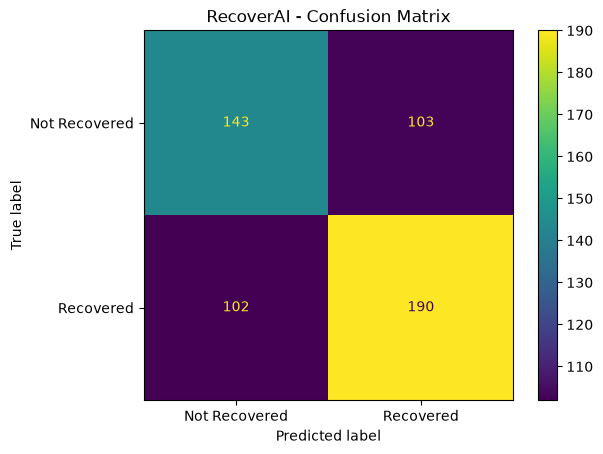

In [54]:
# Import confusion matrix tools
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
print("Confusion Matrix:")
print(cm)

# Create a visual representation
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Recovered", "Recovered"]
)

# Show the confusion matrix
disp.plot()
plt.title("RecoverAI - Confusion Matrix")
plt.show()

In [55]:
# Extract the four values from the confusion matrix
# The order is: TN, FP, FN, TP
tn, fp, fn, tp = cm.ravel()

# Display each value separately
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)


True Negatives : 143
False Positives: 103
False Negatives: 102
True Positives : 190


In [56]:
# Get the trained Random Forest model from our pipeline
rf_model = ml_pipeline.named_steps["model"]

# Get the preprocessing step from our pipeline
preprocessor_fitted = ml_pipeline.named_steps["preprocessor"]

# Get the names of all features after One-Hot Encoding
feature_names = preprocessor_fitted.get_feature_names_out()

# Get the importance of each feature from the Random Forest
importances = rf_model.feature_importances_

# Combine feature names and their importance values
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Sort features from most important to least important
feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

# Display the top 15 most important features
print("Top 15 Important Features:")
print(feature_importance_df.head(15))

Top 15 Important Features:
                                     feature  importance
1                 num__checkout_time_seconds    0.153006
0                                num__amount    0.142871
6                 num__previous_success_rate    0.139012
5               num__customer_lifetime_value    0.138785
2                 num__previous_transactions    0.088074
3                    num__previous_successes    0.081862
4                     num__previous_failures    0.081635
15  cat__failure_reason_Insufficient Balance    0.027788
10                   cat__payment_method_UPI    0.019101
14    cat__failure_reason_Checkout Abandoned    0.017858
7            cat__payment_method_Credit Card    0.017441
13         cat__failure_reason_Card Declined    0.015894
8             cat__payment_method_Debit Card    0.014869
16         cat__failure_reason_Network Error    0.013881
9            cat__payment_method_Net Banking    0.012915


In [57]:
# Predict the probability of successful recovery
# for each transaction in the test dataset
recovery_probabilities = ml_pipeline.predict_proba(X_test)[:, 1]

# Display the first 10 recovery probabilities
print("First 10 recovery probabilities:")

for i, probability in enumerate(recovery_probabilities[:10]):
    print(
        f"Transaction {i+1}: "
        f"{probability:.2%} chance of successful recovery"
    )

First 10 recovery probabilities:
Transaction 1: 61.00% chance of successful recovery
Transaction 2: 78.50% chance of successful recovery
Transaction 3: 35.00% chance of successful recovery
Transaction 4: 38.50% chance of successful recovery
Transaction 5: 72.50% chance of successful recovery
Transaction 6: 39.00% chance of successful recovery
Transaction 7: 52.00% chance of successful recovery
Transaction 8: 62.50% chance of successful recovery
Transaction 9: 73.00% chance of successful recovery
Transaction 10: 61.00% chance of successful recovery


In [58]:
# Create a function to convert recovery probability
# into a business priority level
def assign_priority(probability):

    # 70% or higher means high recovery potential
    if probability >= 0.70:
        return "High"

    # 40% to below 70% means medium potential
    elif probability >= 0.40:
        return "Medium"

    # Below 40% means low recovery potential
    else:
        return "Low"


# Apply the function to every recovery probability
recovery_priority = [
    assign_priority(probability)
    for probability in recovery_probabilities
]

# Display the first 10 priorities
print("First 10 recovery priorities:")

for i, priority in enumerate(recovery_priority[:10]):
    print(f"Transaction {i+1}: {priority}")

First 10 recovery priorities:
Transaction 1: Medium
Transaction 2: High
Transaction 3: Low
Transaction 4: Low
Transaction 5: High
Transaction 6: Low
Transaction 7: Medium
Transaction 8: Medium
Transaction 9: High
Transaction 10: Medium


In [59]:
# Create a function that recommends a recovery action
# based on the reason why the payment failed
def recommend_action(failure_reason):

    # Bank timeout may be temporary,
    # so retrying the payment makes sense
    if failure_reason == "Bank Timeout":
        return "Retry Payment"

    # Network problems can also be temporary,
    # so retrying is appropriate
    elif failure_reason == "Network Error":
        return "Retry Payment"

    # If the card was declined,
    # suggest another payment method
    elif failure_reason == "Card Declined":
        return "Try Another Payment Method"

    # If the customer has insufficient balance,
    # another payment method may work
    elif failure_reason == "Insufficient Balance":
        return "Try Another Payment Method"

    # If checkout was abandoned,
    # remind the customer to complete payment
    elif failure_reason == "Checkout Abandoned":
        return "Send Payment Reminder"

    # Technical errors may be temporary
    elif failure_reason == "Technical Error":
        return "Retry Payment"

    # If there is no failure reason
    else:
        return "No Action"


# Apply the function to every transaction
recommended_actions = [
    recommend_action(reason)
    for reason in ml_df.loc[X_test.index, "failure_reason"]
]

# Display the first 10 recommended actions
print("First 10 recommended actions:")

for i, action in enumerate(recommended_actions[:10]):
    print(f"Transaction {i+1}: {action}")

First 10 recommended actions:
Transaction 1: Retry Payment
Transaction 2: Retry Payment
Transaction 3: Send Payment Reminder
Transaction 4: Retry Payment
Transaction 5: Send Payment Reminder
Transaction 6: Send Payment Reminder
Transaction 7: Retry Payment
Transaction 8: Send Payment Reminder
Transaction 9: Retry Payment
Transaction 10: Send Payment Reminder


In [60]:
# Create a function that makes the final recovery decision
def make_recovery_decision(probability, priority, action):

    # High-priority transactions should be actively recovered
    if priority == "High":
        return action

    # Medium-priority transactions can also be recovered,
    # but with a lower priority
    elif priority == "Medium":
        return action

    # Low-priority transactions are not worth spending
    # recovery effort on
    else:
        return "No Action"


# Create the final decisions for all test transactions
final_decisions = [
    make_recovery_decision(
        probability,
        priority,
        action
    )
    for probability, priority, action in zip(
        recovery_probabilities,
        recovery_priority,
        recommended_actions
    )
]

# Display the first 10 final decisions
print("First 10 final recovery decisions:")

for i, decision in enumerate(final_decisions[:10]):
    print(f"Transaction {i+1}: {decision}")

First 10 final recovery decisions:
Transaction 1: Retry Payment
Transaction 2: Retry Payment
Transaction 3: No Action
Transaction 4: No Action
Transaction 5: Send Payment Reminder
Transaction 6: No Action
Transaction 7: Retry Payment
Transaction 8: Send Payment Reminder
Transaction 9: Retry Payment
Transaction 10: Send Payment Reminder


In [61]:
# Create a copy of the test transactions
# so we can attach our ML results to them
results_df = ml_df.loc[X_test.index].copy()

# Add the recovery probability predicted by our ML model
results_df["recovery_probability"] = recovery_probabilities

# Add the priority assigned by our business rules
results_df["recovery_priority"] = recovery_priority

# Add the recommended recovery action
results_df["recommended_action"] = recommended_actions

# Calculate the potential revenue represented by
# transactions with a recovery probability of 70% or higher
high_confidence_df = results_df[
    results_df["recovery_probability"] >= 0.70
].copy()

# Calculate the total transaction value in this group
potential_revenue = high_confidence_df["amount"].sum()

# Display the result
print(
    "Potential revenue from high-confidence recovery opportunities: ₹",
    round(potential_revenue, 2)
)

# Display how many transactions are in this group
print(
    "High-confidence recovery opportunities:",
    len(high_confidence_df)
)

Potential revenue from high-confidence recovery opportunities: ₹ 1369106.21
High-confidence recovery opportunities: 109


In [62]:
# Count how many high-confidence transactions
# were actually recovered successfully
actual_recovered = high_confidence_df[
    high_confidence_df["recovery_success"] == 1
]

# Calculate the number of successful recoveries
recovered_count = len(actual_recovered)

# Calculate the total revenue from those
# successfully recovered transactions
actual_recovered_revenue = actual_recovered["amount"].sum()

# Calculate the actual recovery rate
# among our high-confidence opportunities
high_confidence_recovery_rate = (
    recovered_count / len(high_confidence_df)
) * 100

# Display the results
print("High-confidence recovery opportunities:", len(high_confidence_df))
print("Actually recovered:", recovered_count)
print(
    "Actual recovered revenue: ₹",
    round(actual_recovered_revenue, 2)
)
print(
    "Actual recovery rate:",
    round(high_confidence_recovery_rate, 2),
    "%"
)

High-confidence recovery opportunities: 109
Actually recovered: 83
Actual recovered revenue: ₹ 994728.46
Actual recovery rate: 76.15 %


In [63]:
# Group our test results by recovery priority
# and calculate the actual recovery performance
priority_performance = results_df.groupby(
    "recovery_priority"
).agg(
    total_opportunities=("recovery_success", "count"),
    recovered_transactions=("recovery_success", "sum"),
    potential_revenue=("amount", "sum"),
    recovered_revenue=(
        "amount",
        lambda x: x[results_df.loc[x.index, "recovery_success"] == 1].sum()
    )
)

# Calculate the actual recovery rate for each priority
priority_performance["recovery_rate_percent"] = (
    priority_performance["recovered_transactions"]
    / priority_performance["total_opportunities"]
) * 100

# Display the results
print("Recovery Performance by Priority:")
print(priority_performance.round(2))

Recovery Performance by Priority:
                   total_opportunities  recovered_transactions  \
recovery_priority                                                
High                               109                      83   
Low                                153                      60   
Medium                             276                     149   

                   potential_revenue  recovered_revenue  recovery_rate_percent  
recovery_priority                                                               
High                      1369106.21          994728.46                  76.15  
Low                       1987613.77          781448.34                  39.22  
Medium                    3398612.26         1812218.38                  53.99  


In [64]:
# Import ROC-AUC metric
from sklearn.metrics import roc_auc_score

# Calculate ROC-AUC using the recovery probabilities
auc_score = roc_auc_score(
    y_test,
    recovery_probabilities
)

# Display the ROC-AUC score
print("ROC-AUC Score:", round(auc_score, 4))

ROC-AUC Score: 0.6735


In [65]:
# Check how many examples belong to each recovery outcome
print("Training target distribution:")
print(y_train.value_counts())

# Calculate the percentage of each class
print("\nTraining target percentage:")
print(
    y_train.value_counts(normalize=True).mul(100).round(2)
)

Training target distribution:
recovery_success
1    1169
0     982
Name: count, dtype: int64

Training target percentage:
recovery_success
1    54.35
0    45.65
Name: proportion, dtype: float64


In [66]:
# Select the numerical features from our ML dataset
numeric_features = [
    "amount",
    "checkout_time_seconds",
    "previous_transactions",
    "previous_successes",
    "previous_failures",
    "customer_lifetime_value",
    "previous_success_rate"
]

# Calculate the average value of each feature
# separately for recovered and non-recovered transactions
feature_comparison = ml_df.groupby(
    "recovery_success"
)[numeric_features].mean().round(2)

# Display the comparison
print("Average feature values by recovery outcome:")
print(feature_comparison)

Average feature values by recovery outcome:
                    amount  checkout_time_seconds  previous_transactions  \
recovery_success                                                           
0                 12325.90                 429.08                  14.67   
1                 12349.08                 468.39                  15.36   

                  previous_successes  previous_failures  \
recovery_success                                          
0                               6.26               8.42   
1                               8.92               6.44   

                  customer_lifetime_value  previous_success_rate  
recovery_success                                                  
0                                72364.19                   0.39  
1                                78445.24                   0.57  


In [67]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create a Logistic Regression model
# max_iter is increased so the model has enough iterations to learn
logistic_model = LogisticRegression(
    max_iter=1000
)

# Create a pipeline
# First preprocess the data
# Then train Logistic Regression
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", logistic_model)
    ]
)

# Train Logistic Regression using the training data
logistic_pipeline.fit(X_train, y_train)

# Confirm training is complete
print("Logistic Regression training completed successfully!")

Logistic Regression training completed successfully!


c:\Users\tlsha\OneDrive\Desktop\RecoverAI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [68]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
# Increase max_iter so the model has enough time to converge
logistic_model = LogisticRegression(
    max_iter=3000
)

# Create a pipeline
# First preprocess the data
# Then train Logistic Regression
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", logistic_model)
    ]
)

# Train Logistic Regression
logistic_pipeline.fit(X_train, y_train)

# Confirm training is complete
print("Logistic Regression training completed successfully!")

Logistic Regression training completed successfully!


c:\Users\tlsha\OneDrive\Desktop\RecoverAI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [69]:
# Import StandardScaler
# It puts numerical features onto a similar scale
from sklearn.preprocessing import StandardScaler

# Create a new numerical preprocessing pipeline
# Missing values are filled first
# Then numerical values are standardized
numeric_transformer_scaled = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Create the complete preprocessing pipeline
# Numerical columns will be scaled
# Categorical columns will be one-hot encoded
preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_scaled,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

# Create Logistic Regression
# 1000 iterations should now be enough after scaling
logistic_model = LogisticRegression(
    max_iter=1000
)

# Combine preprocessing + Logistic Regression
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_scaled),
        ("model", logistic_model)
    ]
)

# Train the complete pipeline
logistic_pipeline.fit(X_train, y_train)

# Confirm training
print("Scaled Logistic Regression trained successfully!")

NameError: name 'SimpleImputer' is not defined

In [70]:
# Make predictions using Logistic Regression
# on the same test data used for Random Forest
logistic_pred = logistic_pipeline.predict(X_test)

# Get the probability of successful recovery
# [:, 1] selects the probability of class 1 (Recovered)
logistic_probabilities = logistic_pipeline.predict_proba(X_test)[:, 1]


# Import the evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Calculate all performance metrics
logistic_accuracy = accuracy_score(y_test, logistic_pred)

logistic_precision = precision_score(y_test, logistic_pred)

logistic_recall = recall_score(y_test, logistic_pred)

logistic_f1 = f1_score(y_test, logistic_pred)

logistic_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)


# Display the results
print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1 Score :", round(logistic_f1, 4))
print("ROC-AUC  :", round(logistic_auc, 4))

Logistic Regression Performance
--------------------------------
Accuracy : 0.6301
Precision: 0.6515
Recall   : 0.6849
F1 Score : 0.6678
ROC-AUC  : 0.6867


In [71]:
# Import Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier

# Create the Gradient Boosting model
gradient_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Create a pipeline
# First preprocess the data
# Then train Gradient Boosting
gradient_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", gradient_model)
    ]
)

# Train the Gradient Boosting model
gradient_pipeline.fit(X_train, y_train)

# Confirm training is complete
print("Gradient Boosting training completed successfully!")

Gradient Boosting training completed successfully!


In [72]:
# Make predictions on the unseen test data
gradient_pred = gradient_pipeline.predict(X_test)

# Get probability of successful recovery
# [:, 1] means probability of class 1 = Recovered
gradient_probabilities = gradient_pipeline.predict_proba(X_test)[:, 1]


# Calculate the performance metrics
gradient_accuracy = accuracy_score(y_test, gradient_pred)

gradient_precision = precision_score(y_test, gradient_pred)

gradient_recall = recall_score(y_test, gradient_pred)

gradient_f1 = f1_score(y_test, gradient_pred)

gradient_auc = roc_auc_score(
    y_test,
    gradient_probabilities
)


# Display the results
print("Gradient Boosting Performance")
print("--------------------------------")
print("Accuracy :", round(gradient_accuracy, 4))
print("Precision:", round(gradient_precision, 4))
print("Recall   :", round(gradient_recall, 4))
print("F1 Score :", round(gradient_f1, 4))
print("ROC-AUC  :", round(gradient_auc, 4))

Gradient Boosting Performance
--------------------------------
Accuracy : 0.6468
Precision: 0.6624
Recall   : 0.7123
F1 Score : 0.6865
ROC-AUC  : 0.6887


In [73]:
# Import cross-validation tools
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation
# The dataset is divided into 5 parts
# The model trains on 4 parts and validates on the remaining part
# This process is repeated 5 times
cv_scores = cross_val_score(
    gradient_pipeline,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

# Display the ROC-AUC score from each fold
print("ROC-AUC scores for each fold:")
print(cv_scores.round(4))

# Calculate the average ROC-AUC
print(
    "\nMean ROC-AUC:",
    round(cv_scores.mean(), 4)
)

# Calculate how much the scores vary
print(
    "Standard deviation:",
    round(cv_scores.std(), 4)
)

ROC-AUC scores for each fold:
[0.6614 0.6657 0.6727 0.7058 0.6518]

Mean ROC-AUC: 0.6715
Standard deviation: 0.0185


Confusion Matrix:
[[140 106]
 [ 84 208]]


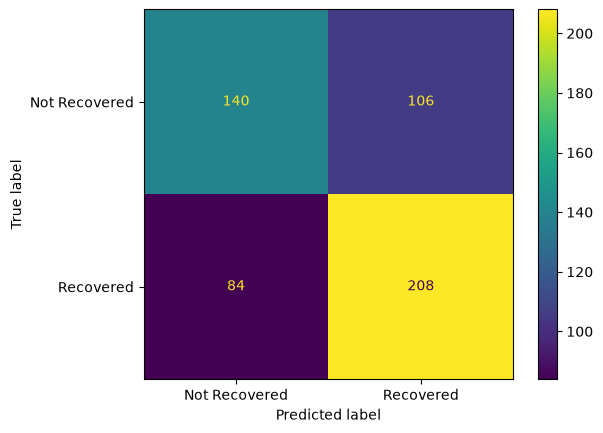

In [74]:
# Import confusion matrix tools
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(
    y_test,
    gradient_pred
)

# Display the confusion matrix
print("Confusion Matrix:")
print(cm)

# Create a visual confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Recovered", "Recovered"]
)

# Display the chart
disp.plot()

# Show the plot
plt.show()

In [75]:
# Create a copy of all failed and abandoned transactions
# These are the transactions that actually need recovery
final_recovery_df = ml_df.copy()

# Predict recovery probability using our best model
# [:, 1] gives the probability of successful recovery
final_recovery_df["recovery_probability"] = (
    gradient_pipeline.predict_proba(X)[:, 1]
)

# Display the first 10 transactions with their probabilities
print(
    final_recovery_df[
        [
            "transaction_id",
            "amount",
            "status",
            "failure_reason",
            "recovery_probability"
        ]
    ].head(10)
)

   transaction_id    amount     status        failure_reason  \
5       TXN000006  23123.58     Failed          Bank Timeout   
6       TXN000007   1499.98  Abandoned    Checkout Abandoned   
7       TXN000008  12192.29     Failed          Bank Timeout   
9       TXN000010  15298.04     Failed         Card Declined   
10      TXN000011  13705.54  Abandoned    Checkout Abandoned   
15      TXN000016  12917.08  Abandoned    Checkout Abandoned   
21      TXN000022   2084.91  Abandoned    Checkout Abandoned   
23      TXN000024  23320.91     Failed  Insufficient Balance   
27      TXN000028  19182.05     Failed  Insufficient Balance   
31      TXN000032  22491.30  Abandoned    Checkout Abandoned   

    recovery_probability  
5               0.590128  
6               0.558172  
7               0.850626  
9               0.259406  
10              0.715304  
15              0.693787  
21              0.465658  
23              0.273598  
27              0.279244  
31              0.566943 

In [76]:
# Display the recovery probability and priority
# for the first 20 failed/abandoned transactions
print(
    final_recovery_df[
        [
            "transaction_id",
            "amount",
            "failure_reason",
            "recovery_probability",
            "recovery_priority"
        ]
    ].head(20)
)


   transaction_id    amount        failure_reason  recovery_probability  \
5       TXN000006  23123.58          Bank Timeout              0.590128   
6       TXN000007   1499.98    Checkout Abandoned              0.558172   
7       TXN000008  12192.29          Bank Timeout              0.850626   
9       TXN000010  15298.04         Card Declined              0.259406   
10      TXN000011  13705.54    Checkout Abandoned              0.715304   
15      TXN000016  12917.08    Checkout Abandoned              0.693787   
21      TXN000022   2084.91    Checkout Abandoned              0.465658   
23      TXN000024  23320.91  Insufficient Balance              0.273598   
27      TXN000028  19182.05  Insufficient Balance              0.279244   
31      TXN000032  22491.30    Checkout Abandoned              0.566943   
36      TXN000037  22729.78  Insufficient Balance              0.204007   
37      TXN000038  19033.96    Checkout Abandoned              0.710797   
39      TXN000040   7594.

In [77]:
# Create a function to recommend the best recovery action
# based on the failure reason and AI priority

def recommend_action(row):

    # Get the failure reason
    reason = row["failure_reason"]

    # Get the AI-generated priority
    priority = row["recovery_priority"]


    # Bank timeout usually means the bank did not respond in time
    # So retrying the payment can make sense
    if reason == "Bank Timeout":
        if priority == "High":
            return "Retry Payment"
        else:
            return "Retry After Delay"


    # Network errors can sometimes be solved by trying again
    elif reason == "Network Error":
        if priority == "High":
            return "Retry Payment"
        else:
            return "Retry After Delay"


    # Card declined means another payment method may work better
    elif reason == "Card Declined":
        return "Suggest Alternative Payment Method"


    # Insufficient balance means retrying immediately may not help
    # A reminder gives the customer a chance to add funds
    elif reason == "Insufficient Balance":
        return "Send Payment Reminder"


    # Abandoned checkout means the customer started but
    # did not complete the payment
    elif reason == "Checkout Abandoned":
        if priority == "High":
            return "Send Urgent Checkout Reminder"
        else:
            return "Send Checkout Reminder"


    # Technical errors may require another attempt
    elif reason == "Technical Error":
        if priority == "High":
            return "Retry Payment"
        else:
            return "Retry After Delay"


    # Safety fallback in case a new failure reason appears
    else:
        return "Manual Review"


# Apply the action recommendation to every transaction
final_recovery_df["recommended_action"] = (
    final_recovery_df.apply(
        recommend_action,
        axis=1
    )
)


# Display the first 20 recommendations
print("Recovery Action Recommendations:")
print(
    final_recovery_df[
        [
            "transaction_id",
            "amount",
            "failure_reason",
            "recovery_probability",
            "recovery_priority",
            "recommended_action"
        ]
    ].head(20)
)

Recovery Action Recommendations:
   transaction_id    amount        failure_reason  recovery_probability  \
5       TXN000006  23123.58          Bank Timeout              0.590128   
6       TXN000007   1499.98    Checkout Abandoned              0.558172   
7       TXN000008  12192.29          Bank Timeout              0.850626   
9       TXN000010  15298.04         Card Declined              0.259406   
10      TXN000011  13705.54    Checkout Abandoned              0.715304   
15      TXN000016  12917.08    Checkout Abandoned              0.693787   
21      TXN000022   2084.91    Checkout Abandoned              0.465658   
23      TXN000024  23320.91  Insufficient Balance              0.273598   
27      TXN000028  19182.05  Insufficient Balance              0.279244   
31      TXN000032  22491.30    Checkout Abandoned              0.566943   
36      TXN000037  22729.78  Insufficient Balance              0.204007   
37      TXN000038  19033.96    Checkout Abandoned              0.71

In [78]:
# Calculate the total value of all recovery opportunities
total_opportunity_value = final_recovery_df["amount"].sum()

# Calculate the value of transactions that were actually recovered
actual_recovered_value = final_recovery_df.loc[
    final_recovery_df["recovery_success"] == 1,
    "amount"
].sum()

# Calculate the overall actual recovery rate
overall_recovery_rate = (
    final_recovery_df["recovery_success"].mean() * 100
)

# Calculate the number of recovery opportunities
total_opportunities = len(final_recovery_df)

# Calculate the number of successfully recovered transactions
total_recovered = final_recovery_df[
    final_recovery_df["recovery_success"] == 1
].shape[0]


# Display the final business metrics
print("========== RecoverAI Business Impact ==========")

print(
    "Total recovery opportunities:",
    total_opportunities
)

print(
    "Total opportunity value: ₹",
    round(total_opportunity_value, 2)
)

print(
    "Successfully recovered transactions:",
    total_recovered
)

print(
    "Actual recovered revenue: ₹",
    round(actual_recovered_value, 2)
)

print(
    "Overall recovery rate:",
    round(overall_recovery_rate, 2),
    "%"
)

========== RecoverAI Business Impact ==========
Total recovery opportunities: 2689
Total opportunity value: ₹ 33178206.41
Successfully recovered transactions: 1461
Actual recovered revenue: ₹ 18042002.98
Overall recovery rate: 54.33 %


In [79]:
# Group transactions by the recommended recovery action
# and calculate how each action performed

action_performance = (
    final_recovery_df
    .groupby("recommended_action")
    .agg(
        total_opportunities=("transaction_id", "count"),
        recovered_transactions=("recovery_success", "sum"),
        potential_revenue=("amount", "sum"),
        recovered_revenue=(
            "amount",
            lambda x: x[
                final_recovery_df.loc[x.index, "recovery_success"] == 1
            ].sum()
        )
    )
)

# Calculate the recovery rate for each action
action_performance["recovery_rate_percent"] = (
    action_performance["recovered_transactions"]
    / action_performance["total_opportunities"]
    * 100
)

# Sort actions by recovery rate
action_performance = action_performance.sort_values(
    by="recovery_rate_percent",
    ascending=False
)

# Round the values for easier reading
action_performance["recovery_rate_percent"] = (
    action_performance["recovery_rate_percent"].round(2)
)

action_performance["potential_revenue"] = (
    action_performance["potential_revenue"].round(2)
)

action_performance["recovered_revenue"] = (
    action_performance["recovered_revenue"].round(2)
)


# Display the results
print("========== Recovery Action Performance ==========")
print(action_performance)

========== Recovery Action Performance ==========
                                    total_opportunities  \
recommended_action                                        
Retry Payment                                       304   
Send Urgent Checkout Reminder                       221   
Retry After Delay                                   746   
Send Checkout Reminder                              729   
Suggest Alternative Payment Method                  353   
Send Payment Reminder                               336   

                                    recovered_transactions  potential_revenue  \
recommended_action                                                              
Retry Payment                                          237         3817003.97   
Send Urgent Checkout Reminder                          168         2923745.55   
Retry After Delay                                      403         9245559.17   
Send Checkout Reminder                                 387         88037

In [80]:
# Analyze recovery performance by failure reason
# and recommended recovery action

action_by_reason = (
    final_recovery_df
    .groupby(
        ["failure_reason", "recommended_action"]
    )
    .agg(
        opportunities=("transaction_id", "count"),
        recovered=("recovery_success", "sum"),
        potential_revenue=("amount", "sum"),
        recovered_revenue=(
            "amount",
            lambda x: x[
                final_recovery_df.loc[
                    x.index,
                    "recovery_success"
                ] == 1
            ].sum()
        )
    )
    .reset_index()
)

# Calculate recovery rate
action_by_reason["recovery_rate_percent"] = (
    action_by_reason["recovered"]
    / action_by_reason["opportunities"]
    * 100
)

# Round the recovery rate
action_by_reason["recovery_rate_percent"] = (
    action_by_reason["recovery_rate_percent"].round(2)
)

# Sort from highest to lowest recovery rate
action_by_reason = action_by_reason.sort_values(
    by="recovery_rate_percent",
    ascending=False
)

# Display the complete analysis
print("========== Recovery Action by Failure Reason ==========")
print(action_by_reason)

========== Recovery Action by Failure Reason ==========
         failure_reason                  recommended_action  opportunities  \
7         Network Error                       Retry Payment            106   
4    Checkout Abandoned       Send Urgent Checkout Reminder            221   
1          Bank Timeout                       Retry Payment            122   
9       Technical Error                       Retry Payment             76   
6         Network Error                   Retry After Delay            254   
0          Bank Timeout                   Retry After Delay            225   
3    Checkout Abandoned              Send Checkout Reminder            729   
8       Technical Error                   Retry After Delay            267   
2         Card Declined  Suggest Alternative Payment Method            353   
5  Insufficient Balance               Send Payment Reminder            336   

   recovered  potential_revenue  recovered_revenue  recovery_rate_percent  
7        

In [81]:
# Calculate the estimated recoverable value
# for each transaction
#
# Example:
# ₹20,000 transaction × 80% recovery probability
# = ₹16,000 estimated recovery opportunity

final_recovery_df["estimated_recovery_value"] = (
    final_recovery_df["amount"]
    * final_recovery_df["recovery_probability"]
)


# Sort transactions by estimated recovery value
# Highest-value opportunities come first
top_opportunities = final_recovery_df.sort_values(
    by="estimated_recovery_value",
    ascending=False
)


# Display the top 20 opportunities
print("========== Top Recovery Opportunities ==========")

print(
    top_opportunities[
        [
            "transaction_id",
            "amount",
            "failure_reason",
            "recovery_probability",
            "recovery_priority",
            "recommended_action",
            "estimated_recovery_value"
        ]
    ].head(20)
)


========== Top Recovery Opportunities ==========
     transaction_id    amount      failure_reason  recovery_probability  \
1262      TXN001263  24199.83  Checkout Abandoned              0.892553   
7293      TXN007294  24483.03       Card Declined              0.869466   
6695      TXN006696  23527.50       Network Error              0.895521   
3387      TXN003388  24308.52  Checkout Abandoned              0.863423   
453       TXN000454  24363.54       Network Error              0.860269   
3687      TXN003688  24801.20        Bank Timeout              0.843672   
889       TXN000890  24062.22     Technical Error              0.868087   
9071      TXN009072  24242.34  Checkout Abandoned              0.856021   
8981      TXN008982  24367.77       Network Error              0.844692   
8584      TXN008585  23655.45       Network Error              0.845218   
1753      TXN001754  23953.69       Network Error              0.831561   
2948      TXN002949  24144.76       Network Error  

In [82]:
# Select the top 10 highest-value recovery opportunities
top_10_recovery = top_opportunities.head(10).copy()

# Select only the important columns for the final business view
top_10_recovery = top_10_recovery[
    [
        "transaction_id",
        "amount",
        "failure_reason",
        "recovery_probability",
        "recovery_priority",
        "recommended_action",
        "estimated_recovery_value"
    ]
]

# Round probability and money values
top_10_recovery["recovery_probability"] = (
    top_10_recovery["recovery_probability"] * 100
).round(2)

top_10_recovery["estimated_recovery_value"] = (
    top_10_recovery["estimated_recovery_value"]
).round(2)

# Display the final top 10 list
print("========== TOP 10 RECOVERY OPPORTUNITIES ==========")
print(top_10_recovery.to_string(index=False))

========== TOP 10 RECOVERY OPPORTUNITIES ==========
transaction_id   amount     failure_reason  recovery_probability recovery_priority                 recommended_action  estimated_recovery_value
     TXN001263 24199.83 Checkout Abandoned                 89.26              High      Send Urgent Checkout Reminder                  21599.62
     TXN007294 24483.03      Card Declined                 86.95            Medium Suggest Alternative Payment Method                  21287.17
     TXN006696 23527.50      Network Error                 89.55              High                      Retry Payment                  21069.38
     TXN003388 24308.52 Checkout Abandoned                 86.34              High      Send Urgent Checkout Reminder                  20988.54
     TXN000454 24363.54      Network Error                 86.03              High                      Retry Payment                  20959.20
     TXN003688 24801.20       Bank Timeout                 84.37              High  

In [83]:
# Recalculate the recovery priority using the latest probabilities
final_recovery_df["recovery_priority"] = (
    final_recovery_df["recovery_probability"]
    .apply(assign_priority)
)

# Recreate the ranked recovery opportunities
top_opportunities = final_recovery_df.sort_values(
    by="estimated_recovery_value",
    ascending=False
)

# Create the final Top 10 list again
top_10_recovery = top_opportunities.head(10).copy()

# Display the important columns
print(
    top_10_recovery[
        [
            "transaction_id",
            "amount",
            "failure_reason",
            "recovery_probability",
            "recovery_priority",
            "recommended_action",
            "estimated_recovery_value"
        ]
    ].to_string(index=False)
)

transaction_id   amount     failure_reason  recovery_probability recovery_priority                 recommended_action  estimated_recovery_value
     TXN001263 24199.83 Checkout Abandoned              0.892553              High      Send Urgent Checkout Reminder              21599.623175
     TXN007294 24483.03      Card Declined              0.869466              High Suggest Alternative Payment Method              21287.171857
     TXN006696 23527.50      Network Error              0.895521              High                      Retry Payment              21069.380421
     TXN003388 24308.52 Checkout Abandoned              0.863423              High      Send Urgent Checkout Reminder              20988.539422
     TXN000454 24363.54      Network Error              0.860269              High                      Retry Payment              20959.203609
     TXN003688 24801.20       Bank Timeout              0.843672              High                      Retry Payment              20924

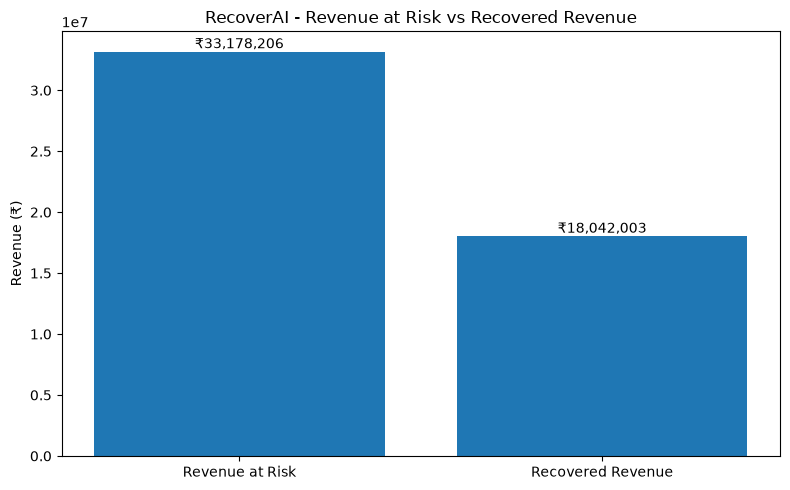

In [84]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Create the values we want to compare
revenue_labels = [
    "Revenue at Risk",
    "Recovered Revenue"
]

revenue_values = [
    total_opportunity_value,
    actual_recovered_value
]

# Create the bar chart
plt.figure(figsize=(8, 5))

plt.bar(
    revenue_labels,
    revenue_values
)

# Add chart title
plt.title("RecoverAI - Revenue at Risk vs Recovered Revenue")

# Add y-axis label
plt.ylabel("Revenue (₹)")

# Display the exact values above each bar
for i, value in enumerate(revenue_values):
    plt.text(
        i,
        value,
        f"₹{value:,.0f}",
        ha="center",
        va="bottom"
    )

# Make the layout neat
plt.tight_layout()

# Display the chart
plt.show()

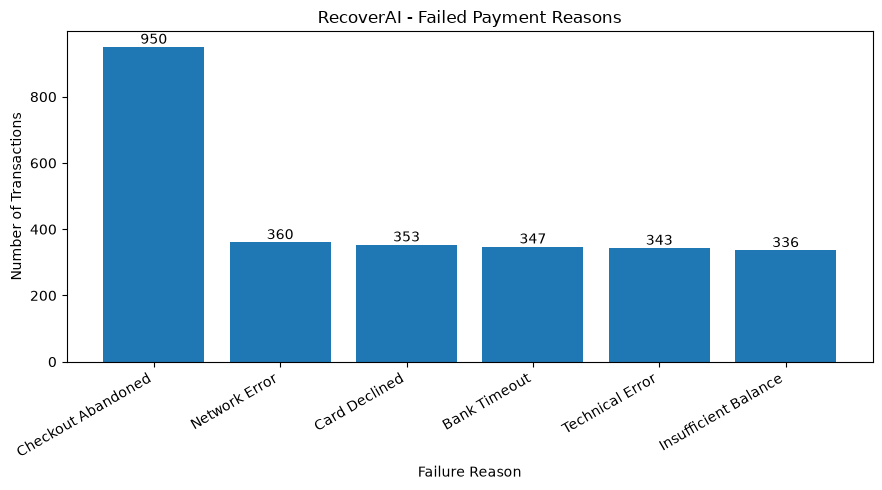

In [85]:
# Count how many transactions occurred for each failure reason
failure_counts = (
    final_recovery_df["failure_reason"]
    .value_counts()
)

# Create the bar chart
plt.figure(figsize=(9, 5))

plt.bar(
    failure_counts.index,
    failure_counts.values
)

# Add chart title
plt.title("RecoverAI - Failed Payment Reasons")

# Add axis labels
plt.xlabel("Failure Reason")
plt.ylabel("Number of Transactions")

# Rotate the x-axis labels
# so they are easier to read
plt.xticks(rotation=30, ha="right")

# Add the exact number above each bar
for i, value in enumerate(failure_counts.values):
    plt.text(
        i,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

# Keep the chart neat
plt.tight_layout()

# Display the chart
plt.show()

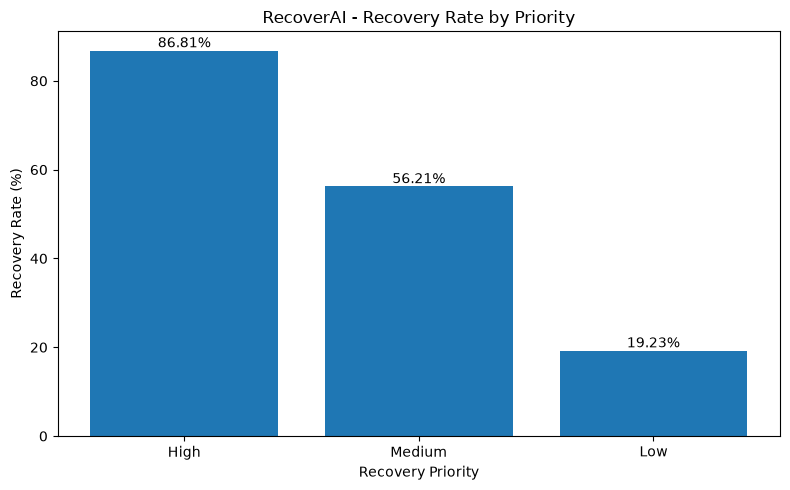

In [86]:
# Calculate recovery performance by priority
priority_performance = (
    final_recovery_df
    .groupby("recovery_priority")
    .agg(
        total_opportunities=("transaction_id", "count"),
        recovered_transactions=("recovery_success", "sum")
    )
)

# Calculate recovery rate for each priority
priority_performance["recovery_rate_percent"] = (
    priority_performance["recovered_transactions"]
    / priority_performance["total_opportunities"]
    * 100
)

# Put the priorities in the correct business order
priority_order = ["High", "Medium", "Low"]

priority_performance = (
    priority_performance
    .reindex(priority_order)
)

# Create the chart
plt.figure(figsize=(8, 5))

plt.bar(
    priority_performance.index,
    priority_performance["recovery_rate_percent"]
)

# Add chart title
plt.title("RecoverAI - Recovery Rate by Priority")

# Add axis labels
plt.xlabel("Recovery Priority")
plt.ylabel("Recovery Rate (%)")

# Add the percentage above each bar
for i, value in enumerate(
    priority_performance["recovery_rate_percent"]
):
    plt.text(
        i,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

# Keep the chart neat
plt.tight_layout()

# Display the chart
plt.show()

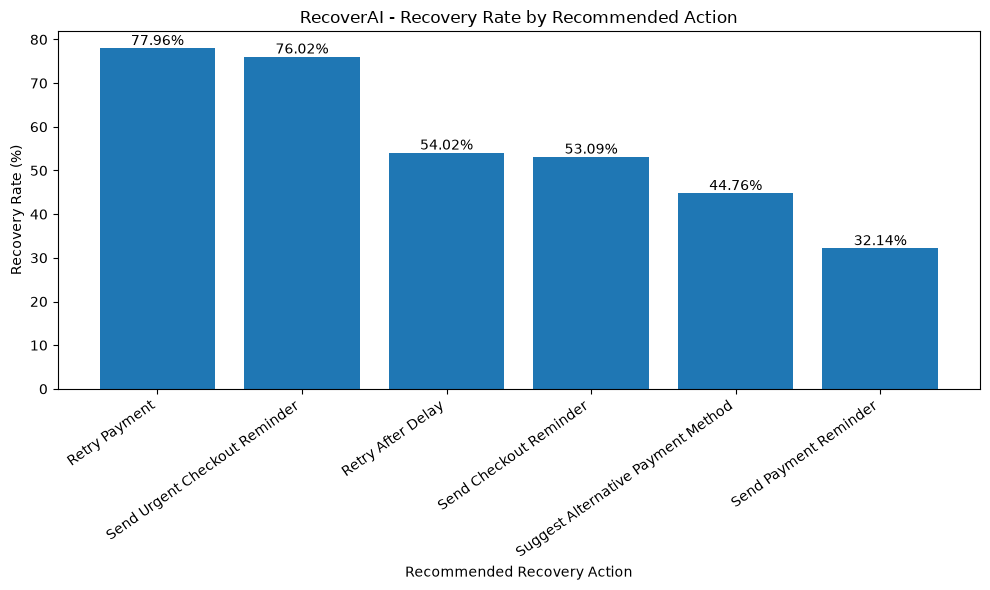

In [87]:
# Calculate recovery performance for each recommended action
action_chart = (
    final_recovery_df
    .groupby("recommended_action")
    .agg(
        total_opportunities=("transaction_id", "count"),
        recovered_transactions=("recovery_success", "sum")
    )
)

# Calculate the recovery rate
action_chart["recovery_rate_percent"] = (
    action_chart["recovered_transactions"]
    / action_chart["total_opportunities"]
    * 100
)

# Sort actions from highest recovery rate to lowest
action_chart = action_chart.sort_values(
    by="recovery_rate_percent",
    ascending=False
)

# Create the bar chart
plt.figure(figsize=(10, 6))

plt.bar(
    action_chart.index,
    action_chart["recovery_rate_percent"]
)

# Add chart title
plt.title("RecoverAI - Recovery Rate by Recommended Action")

# Add axis labels
plt.xlabel("Recommended Recovery Action")
plt.ylabel("Recovery Rate (%)")

# Rotate action names so they don't overlap
plt.xticks(
    rotation=35,
    ha="right"
)

# Add the recovery percentage above each bar
for i, value in enumerate(
    action_chart["recovery_rate_percent"]
):
    plt.text(
        i,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

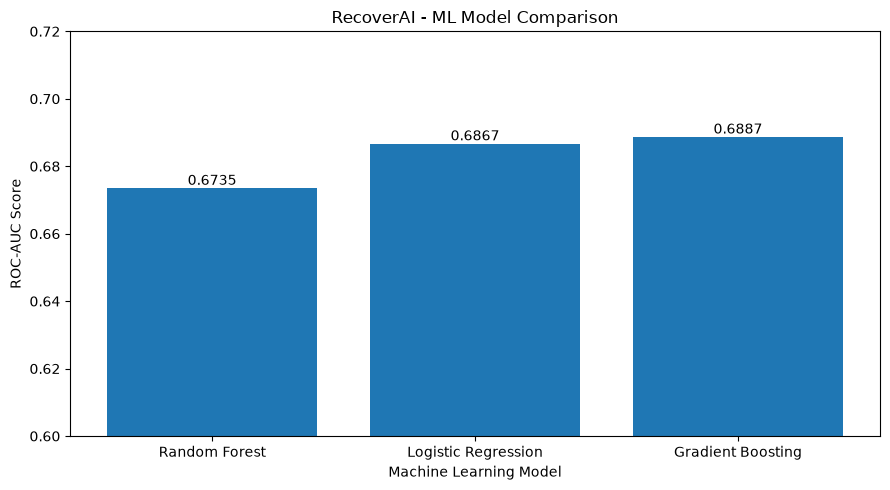

In [88]:
# Store the performance scores of our three ML models
model_names = [
    "Random Forest",
    "Logistic Regression",
    "Gradient Boosting"
]

# ROC-AUC scores obtained from our model evaluation
roc_auc_scores = [
    0.6735,
    0.6867,
    0.6887
]

# Create the comparison chart
plt.figure(figsize=(9, 5))

plt.bar(
    model_names,
    roc_auc_scores
)

# Add chart title
plt.title("RecoverAI - ML Model Comparison")

# Add axis labels
plt.xlabel("Machine Learning Model")
plt.ylabel("ROC-AUC Score")

# Set a suitable y-axis range
plt.ylim(0.60, 0.72)

# Display the exact ROC-AUC score above each bar
for i, value in enumerate(roc_auc_scores):
    plt.text(
        i,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

# Keep the chart neat
plt.tight_layout()

# Display the chart
plt.show()

In [89]:
# Create a summary of all ML model performances
model_performance = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Logistic Regression",
        "Gradient Boosting"
    ],
    
    "Accuracy": [
        0.6190,
        0.6301,
        0.6468
    ],
    
    "Precision": [
        0.6485,
        0.6515,
        0.6624
    ],
    
    "Recall": [
        0.6507,
        0.6849,
        0.7123
    ],
    
    "F1 Score": [
        0.6496,
        0.6678,
        0.6865
    ],
    
    "ROC-AUC": [
        0.6735,
        0.6867,
        0.6887
    ]
})

# Display the model comparison table
print("========== ML MODEL PERFORMANCE ==========")
print(model_performance.to_string(index=False))

========== ML MODEL PERFORMANCE ==========
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
      Random Forest    0.6190     0.6485  0.6507    0.6496   0.6735
Logistic Regression    0.6301     0.6515  0.6849    0.6678   0.6867
  Gradient Boosting    0.6468     0.6624  0.7123    0.6865   0.6887


In [90]:
# Create the main business KPIs for RecoverAI

print("==============================================")
print("             RecoverAI FINAL SUMMARY")
print("==============================================")

# Total transactions in the original dataset
print(
    "\nTotal Transactions:",
    len(recovery_df)
)

# Failed + abandoned transactions
print(
    "Recovery Opportunities:",
    len(final_recovery_df)
)

# Total amount involved in failed/abandoned transactions
print(
    "Revenue at Risk: ₹",
    round(total_opportunity_value, 2)
)

# Amount successfully recovered in the simulated outcomes
print(
    "Recovered Revenue: ₹",
    round(actual_recovered_value, 2)
)

# Overall recovery rate
print(
    "Overall Recovery Rate:",
    round(overall_recovery_rate, 2),
    "%"
)

# Number of successfully recovered transactions
print(
    "Recovered Transactions:",
    total_recovered
)

# Best ML model
print(
    "\nBest ML Model: Gradient Boosting"
)

# Best model's main performance metrics
print(
    "Model Accuracy: 64.68%"
)

print(
    "Model Precision: 66.24%"
)

print(
    "Model Recall: 71.23%"
)

print(
    "Model F1 Score: 68.65%"
)

print(
    "Model ROC-AUC: 0.6887"
)

print("==============================================")

             RecoverAI FINAL SUMMARY

Total Transactions: 10000
Recovery Opportunities: 2689
Revenue at Risk: ₹ 33178206.41
Recovered Revenue: ₹ 18042002.98
Overall Recovery Rate: 54.33 %
Recovered Transactions: 1461

Best ML Model: Gradient Boosting
Model Accuracy: 64.68%
Model Precision: 66.24%
Model Recall: 71.23%
Model F1 Score: 68.65%
Model ROC-AUC: 0.6887


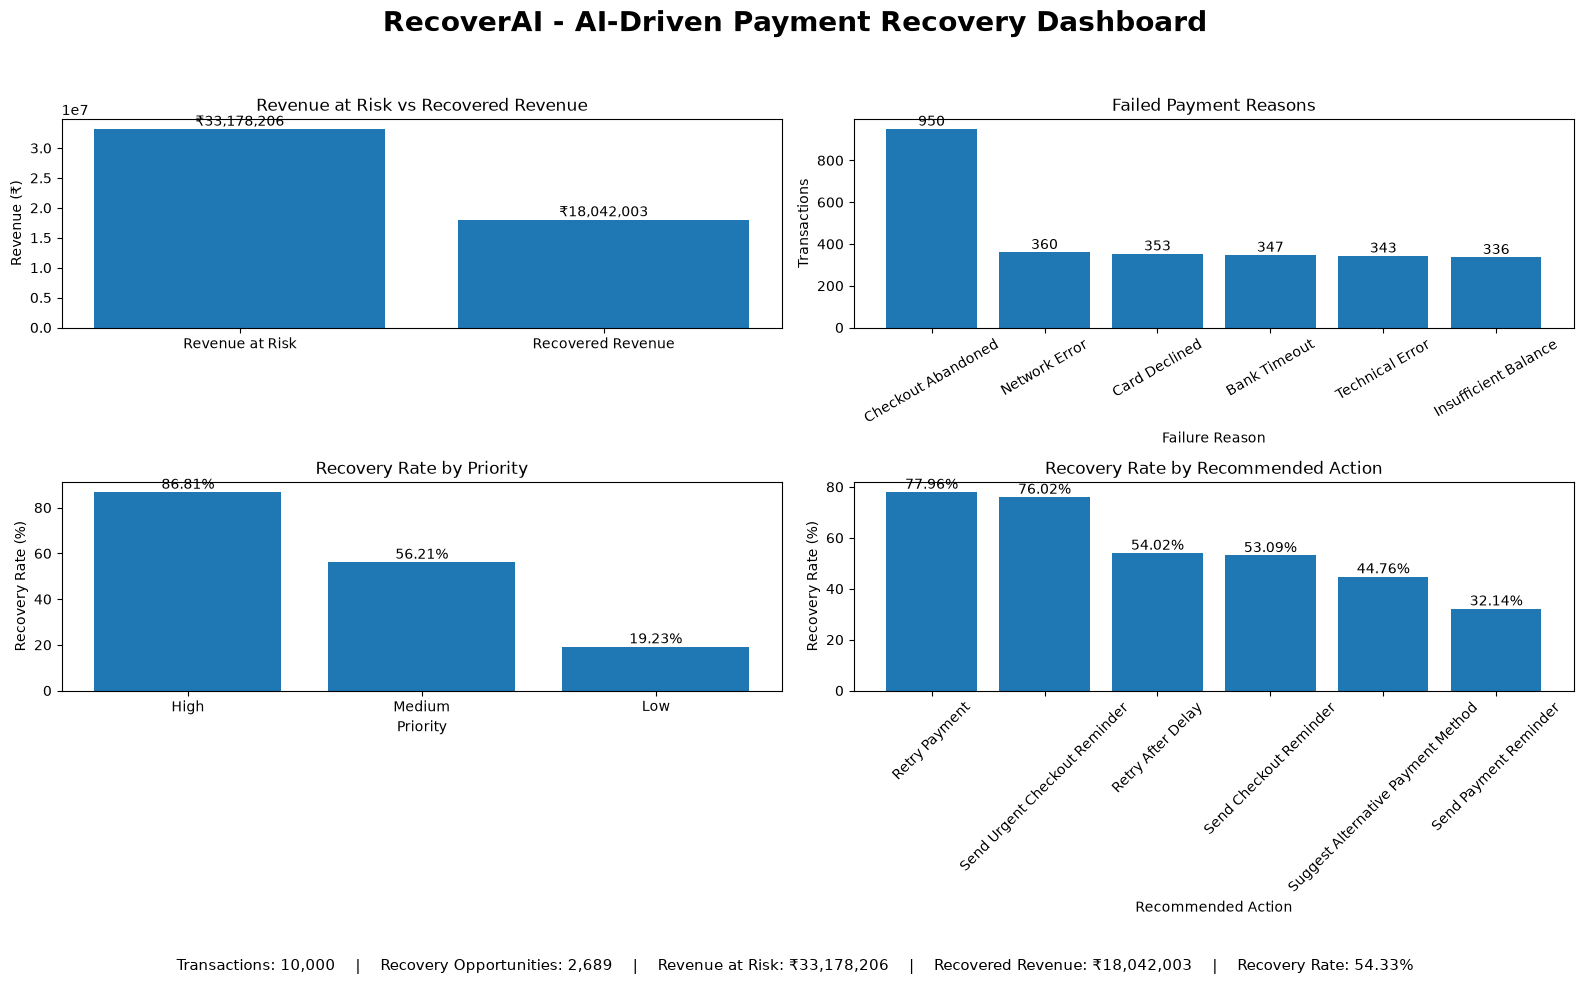

In [91]:
# ============================================================
# STEP 66 - FINAL RECOVERAI DASHBOARD
# ============================================================

# Import pandas and matplotlib
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. CALCULATE MAIN BUSINESS KPIs
# ------------------------------------------------------------

# Total number of transactions
total_transactions = len(recovery_df)

# Number of failed and abandoned transactions
recovery_opportunities = len(final_recovery_df)

# Total money involved in failed/abandoned transactions
revenue_at_risk = final_recovery_df["amount"].sum()

# Money from transactions that were successfully recovered
recovered_revenue = final_recovery_df.loc[
    final_recovery_df["recovery_success"] == 1,
    "amount"
].sum()

# Number of successfully recovered transactions
recovered_transactions = final_recovery_df[
    final_recovery_df["recovery_success"] == 1
].shape[0]

# Overall recovery rate
overall_recovery_rate = (
    recovered_transactions
    / recovery_opportunities
    * 100
)


# ------------------------------------------------------------
# 2. PREPARE FAILURE REASON DATA
# ------------------------------------------------------------

# Count each type of failure
failure_counts = (
    final_recovery_df["failure_reason"]
    .value_counts()
)


# ------------------------------------------------------------
# 3. PREPARE PRIORITY DATA
# ------------------------------------------------------------

# Calculate recovery rate for each priority
priority_data = (
    final_recovery_df
    .groupby("recovery_priority")
    .agg(
        opportunities=("transaction_id", "count"),
        recovered=("recovery_success", "sum")
    )
)

# Calculate percentage recovery rate
priority_data["recovery_rate"] = (
    priority_data["recovered"]
    / priority_data["opportunities"]
    * 100
)

# Keep the business order
priority_data = priority_data.reindex(
    ["High", "Medium", "Low"]
)


# ------------------------------------------------------------
# 4. PREPARE ACTION DATA
# ------------------------------------------------------------

# Calculate recovery rate for each recommended action
action_data = (
    final_recovery_df
    .groupby("recommended_action")
    .agg(
        opportunities=("transaction_id", "count"),
        recovered=("recovery_success", "sum")
    )
)

# Calculate recovery percentage
action_data["recovery_rate"] = (
    action_data["recovered"]
    / action_data["opportunities"]
    * 100
)

# Sort actions from best to worst
action_data = action_data.sort_values(
    by="recovery_rate",
    ascending=False
)


# ------------------------------------------------------------
# 5. CREATE DASHBOARD
# ------------------------------------------------------------

# Create a 2 x 2 dashboard layout
fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 10)
)

# Give the dashboard an overall title
fig.suptitle(
    "RecoverAI - AI-Driven Payment Recovery Dashboard",
    fontsize=20,
    fontweight="bold"
)


# ============================================================
# CHART 1 - REVENUE AT RISK VS RECOVERED REVENUE
# ============================================================

revenue_labels = [
    "Revenue at Risk",
    "Recovered Revenue"
]

revenue_values = [
    revenue_at_risk,
    recovered_revenue
]

axes[0, 0].bar(
    revenue_labels,
    revenue_values
)

axes[0, 0].set_title(
    "Revenue at Risk vs Recovered Revenue"
)

axes[0, 0].set_ylabel(
    "Revenue (₹)"
)

# Add values above the bars
for i, value in enumerate(revenue_values):
    axes[0, 0].text(
        i,
        value,
        f"₹{value:,.0f}",
        ha="center",
        va="bottom"
    )


# ============================================================
# CHART 2 - FAILURE REASONS
# ============================================================

axes[0, 1].bar(
    failure_counts.index,
    failure_counts.values
)

axes[0, 1].set_title(
    "Failed Payment Reasons"
)

axes[0, 1].set_xlabel(
    "Failure Reason"
)

axes[0, 1].set_ylabel(
    "Transactions"
)

# Rotate labels
axes[0, 1].tick_params(
    axis="x",
    rotation=30
)

# Add counts above bars
for i, value in enumerate(failure_counts.values):
    axes[0, 1].text(
        i,
        value,
        str(value),
        ha="center",
        va="bottom"
    )


# ============================================================
# CHART 3 - RECOVERY RATE BY PRIORITY
# ============================================================

axes[1, 0].bar(
    priority_data.index,
    priority_data["recovery_rate"]
)

axes[1, 0].set_title(
    "Recovery Rate by Priority"
)

axes[1, 0].set_xlabel(
    "Priority"
)

axes[1, 0].set_ylabel(
    "Recovery Rate (%)"
)

# Add percentages above bars
for i, value in enumerate(
    priority_data["recovery_rate"]
):
    axes[1, 0].text(
        i,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )


# ============================================================
# CHART 4 - RECOVERY RATE BY ACTION
# ============================================================

axes[1, 1].bar(
    action_data.index,
    action_data["recovery_rate"]
)

axes[1, 1].set_title(
    "Recovery Rate by Recommended Action"
)

axes[1, 1].set_xlabel(
    "Recommended Action"
)

axes[1, 1].set_ylabel(
    "Recovery Rate (%)"
)

# Rotate action names
axes[1, 1].tick_params(
    axis="x",
    rotation=45
)

# Add percentages above bars
for i, value in enumerate(
    action_data["recovery_rate"]
):
    axes[1, 1].text(
        i,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )


# ------------------------------------------------------------
# 6. ADD KPI SUMMARY TO THE DASHBOARD
# ------------------------------------------------------------

kpi_text = (
    f"Transactions: {total_transactions:,}    |    "
    f"Recovery Opportunities: {recovery_opportunities:,}    |    "
    f"Revenue at Risk: ₹{revenue_at_risk:,.0f}    |    "
    f"Recovered Revenue: ₹{recovered_revenue:,.0f}    |    "
    f"Recovery Rate: {overall_recovery_rate:.2f}%"
)

fig.text(
    0.5,
    0.02,
    kpi_text,
    ha="center",
    fontsize=11
)


# ------------------------------------------------------------
# 7. ADJUST SPACING
# ------------------------------------------------------------

plt.tight_layout(
    rect=[0, 0.06, 1, 0.95]
)

# Display the final dashboard
plt.show()

In [92]:
# Import joblib
# joblib is used to save and load trained ML models
import joblib

# Make sure the models folder exists
import os

os.makedirs("../models", exist_ok=True)

# Save the complete Gradient Boosting pipeline
# IMPORTANT:
# If your trained pipeline has a different variable name,
# replace "gradient_pipeline" with that variable name.
joblib.dump(
    gradient_pipeline,
    "../models/gradient_boosting_pipeline.pkl"
)

# Confirm that the model was saved
print("Gradient Boosting model saved successfully!")
print("Location: ../models/gradient_boosting_pipeline.pkl")

Gradient Boosting model saved successfully!
Location: ../models/gradient_boosting_pipeline.pkl


In [93]:
# Import joblib
# We use it to load our saved ML pipeline
import joblib

# Load the saved Gradient Boosting pipeline
loaded_model = joblib.load(
    "../models/gradient_boosting_pipeline.pkl"
)

# Confirm that the model was loaded
print("Saved Gradient Boosting model loaded successfully!")


# ---------------------------------------------------------
# TEST THE MODEL ON OUR TEST DATA
# ---------------------------------------------------------

# Use the loaded model to predict recovery outcomes
test_predictions = loaded_model.predict(X_test)

# Get recovery probabilities
# [:, 1] means probability of class 1 = Recovery Successful
test_probabilities = loaded_model.predict_proba(X_test)[:, 1]

# Display a few predictions
print("\nFirst 10 predictions:")
print(test_predictions[:10])

# Display the corresponding probabilities
print("\nFirst 10 recovery probabilities:")
print(test_probabilities[:10])

Saved Gradient Boosting model loaded successfully!

First 10 predictions:
[1 1 0 0 1 1 1 1 1 1]

First 10 recovery probabilities:
[0.61204191 0.75348524 0.37761509 0.46161337 0.77528987 0.58051055
 0.61482959 0.74448865 0.77809772 0.64390601]


In [98]:
# ============================================================
# STEP 69 - RECOVERAI PREDICTION FUNCTION
# ============================================================

def recover_payment(
    amount,
    payment_method,
    failure_reason,
    checkout_time_seconds,
    previous_transactions,
    previous_successes,
    previous_failures,
    customer_lifetime_value,
    previous_success_rate
):
    """
    Predict whether a failed/abandoned payment
    is worth trying to recover.
    """

    # --------------------------------------------------------
    # 1. Create a DataFrame containing the transaction
    # --------------------------------------------------------

    transaction = pd.DataFrame({
        "amount": [amount],
        "payment_method": [payment_method],
        "failure_reason": [failure_reason],
        "checkout_time_seconds": [checkout_time_seconds],
        "previous_transactions": [previous_transactions],
        "previous_successes": [previous_successes],
        "previous_failures": [previous_failures],
        "customer_lifetime_value": [customer_lifetime_value],
        "previous_success_rate": [previous_success_rate]
    })


    # --------------------------------------------------------
    # 2. Predict recovery probability
    # --------------------------------------------------------

    # [:, 1] gets the probability of successful recovery
    recovery_probability = loaded_model.predict_proba(
        transaction
    )[0, 1]


    # --------------------------------------------------------
    # 3. Convert probability into priority
    # --------------------------------------------------------

    if recovery_probability >= 0.70:

        priority = "High"

    elif recovery_probability >= 0.40:

        priority = "Medium"

    else:

        priority = "Low"


    # --------------------------------------------------------
    # 4. Select recovery action
    # --------------------------------------------------------

    # Checkout abandonment → remind customer to complete payment
    if failure_reason == "Checkout Abandoned":

        if recovery_probability >= 0.70:
            recommended_action = "Send Urgent Checkout Reminder"
        else:
            recommended_action = "Send Checkout Reminder"


    # Card decline → suggest another payment method
    elif failure_reason == "Card Declined":

        recommended_action = "Suggest Alternative Payment Method"


    # Insufficient balance → remind customer about payment
    elif failure_reason == "Insufficient Balance":

        recommended_action = "Send Payment Reminder"


    # Network/bank/technical problems → retry payment
    elif failure_reason in [
        "Network Error",
        "Bank Timeout",
        "Technical Error"
    ]:

        if recovery_probability >= 0.70:
            recommended_action = "Retry Payment"
        else:
            recommended_action = "Retry After Delay"


    # Fallback action
    else:

        recommended_action = "Retry After Delay"


    # --------------------------------------------------------
    # 5. Estimate the recoverable amount
    # --------------------------------------------------------

    estimated_recovery_value = (
        amount * recovery_probability
    )


    # --------------------------------------------------------
    # 6. Return all important business results
    # --------------------------------------------------------

    return {
        "recovery_probability": round(
            recovery_probability * 100,
            2
        ),

        "recovery_priority": priority,

        "recommended_action": recommended_action,

        "estimated_recovery_value": round(
            estimated_recovery_value,
            2
        )
    }

In [99]:
# Test RecoverAI with one real transaction
# from our dataset

result = recover_payment(
    amount=23123.58,
    payment_method="UPI",
    failure_reason="Bank Timeout",
    checkout_time_seconds=450,
    previous_transactions=15,
    previous_successes=9,
    previous_failures=6,
    customer_lifetime_value=78000,
    previous_success_rate=0.60
)

# Display the prediction results
print("========== RecoverAI Prediction ==========")

print(
    "Recovery Probability:",
    result["recovery_probability"],
    "%"
)

print(
    "Recovery Priority:",
    result["recovery_priority"]
)

print(
    "Recommended Action:",
    result["recommended_action"]
)

print(
    "Estimated Recovery Value: ₹",
    result["estimated_recovery_value"]
)

========== RecoverAI Prediction ==========
Recovery Probability: 61.28 %
Recovery Priority: Medium
Recommended Action: Retry After Delay
Estimated Recovery Value: ₹ 14170.09


In [100]:
# Select the first failed or abandoned transaction
# from our final dataset

test_transaction = final_recovery_df[
    final_recovery_df["status"].isin(
        ["Failed", "Abandoned"]
    )
].iloc[0]

# Send the real transaction values to RecoverAI
result = recover_payment(
    amount=test_transaction["amount"],
    payment_method=test_transaction["payment_method"],
    failure_reason=test_transaction["failure_reason"],
    checkout_time_seconds=test_transaction["checkout_time_seconds"],
    previous_transactions=test_transaction["previous_transactions"],
    previous_successes=test_transaction["previous_successes"],
    previous_failures=test_transaction["previous_failures"],
    customer_lifetime_value=test_transaction["customer_lifetime_value"],
    previous_success_rate=test_transaction["previous_success_rate"]
)

# Display the original transaction
print("========== INPUT TRANSACTION ==========")

print(
    "Transaction ID:",
    test_transaction["transaction_id"]
)

print(
    "Amount: ₹",
    test_transaction["amount"]
)

print(
    "Payment Method:",
    test_transaction["payment_method"]
)

print(
    "Failure Reason:",
    test_transaction["failure_reason"]
)


# Display RecoverAI's decision
print("\n========== RECOVERAI DECISION ==========")

print(
    "Recovery Probability:",
    result["recovery_probability"],
    "%"
)

print(
    "Recovery Priority:",
    result["recovery_priority"]
)

print(
    "Recommended Action:",
    result["recommended_action"]
)

print(
    "Estimated Recovery Value: ₹",
    result["estimated_recovery_value"]
)

========== INPUT TRANSACTION ==========
Transaction ID: TXN000006
Amount: ₹ 23123.58
Payment Method: UPI
Failure Reason: Bank Timeout

========== RECOVERAI DECISION ==========
Recovery Probability: 59.01 %
Recovery Priority: Medium
Recommended Action: Retry After Delay
Estimated Recovery Value: ₹ 13645.87
